In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import gaussian_kde
from math import sqrt, pi
import pickle
from collections import defaultdict

## 데이터 불러오기

수요 공급 곡선 데이터 7/1-29

In [2]:
files = glob.glob("filteredcurve_202507*.csv")
df_list = []
for fn in files:
    temp = pd.read_csv(fn, encoding="utf-8-sig")

    # 파일명에서 날짜 추출
    date_str = fn.split("_")[-1].split(".")[0]   # "20250720"
    temp["Date"] = pd.to_datetime(date_str, format="%Y%m%d")

    # 공급곡선의 Period → Hour 변환 (1~24 → 0~23)
    temp = temp.dropna(subset=["Time Period"])
    temp["Hour"] = temp["Time Period"].astype(int)

    # Datetime 만들기 (같은 포맷: "20250720 0")
    temp["Datetime"] = temp["Date"].dt.strftime("%Y%m%d") + " " + temp["Hour"].astype(str)

    df_list.append(temp)

df_supply = pd.concat(df_list, ignore_index=True)

print(df_supply[["Date", "Hour", "Datetime"]].head())

        Date  Hour    Datetime
0 2025-07-01     1  20250701 1
1 2025-07-01     1  20250701 1
2 2025-07-01     1  20250701 1
3 2025-07-01     1  20250701 1
4 2025-07-01     1  20250701 1


날씨 데이터

In [3]:
df_weather = pd.read_csv("weather_transformed.csv")

df_weather["T"] = pd.to_numeric(df_weather["T"], errors="coerce")
df_weather["ff"] = pd.to_numeric(df_weather["ff"], errors="coerce")

# Hour → 숫자로 변환 (변환 불가는 NaN)
df_weather["Hour"] = pd.to_numeric(df_weather["Hour"], errors="coerce")

# NaN 값 제거
df_weather = df_weather.dropna(subset=["Hour"])

# int 변환
df_weather["Hour"] = df_weather["Hour"].astype(int)

# Date를 datetime으로 변환
df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce")

# Datetime 생성: "20250731 13"
df_weather["Datetime"] = df_weather["Date"].dt.strftime("%Y%m%d") + " " + df_weather["Hour"].astype(str)

df_weather["Weekday"] = df_weather["Date"].dt.weekday  

# 주말 여부 (토=5, 일=6 → True)
df_weather["IsWeekend"] = df_weather["Weekday"].isin([5, 6])

print(df_weather[["Date", "Hour", "Datetime", "Weekday", "IsWeekend"]].head(100))

          Date  Hour     Datetime  Weekday  IsWeekend
1   2025-07-31    24  20250731 24        3      False
2   2025-07-31    23  20250731 23        3      False
3   2025-07-31    22  20250731 22        3      False
4   2025-07-31    21  20250731 21        3      False
5   2025-07-31    20  20250731 20        3      False
..         ...   ...          ...      ...        ...
97  2025-07-28     1   20250728 1        0      False
98  2025-07-27    24  20250727 24        6       True
99  2025-07-27    23  20250727 23        6       True
100 2025-07-27    22  20250727 22        6       True
101 2025-07-27    21  20250727 21        6       True

[100 rows x 5 columns]


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_22112\2741458697.py:16: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce")


예측 수요 데이터

In [4]:
file_path = "demandforecast0903.xls"

# 1. HTML로 읽기 시도
try:
    dfs = pd.read_html(file_path)
    read_type = "html"
    df_forecast = dfs[0]
except Exception as e_html:
    # 2. CSV로 읽기 시도
    try:
        df_forecast = pd.read_csv(file_path)
        read_type = "csv"
    except Exception as e_csv:
        df_forecast = None
        read_type = f"fail: {e_csv}"

(read_type, df_forecast.head() if df_forecast is not None else None)

# 1. 컬럼 정리 (첫 행이 컬럼명이면 이 과정 필요)
df_forecast.columns = df_forecast.iloc[0]   # 첫 번째 행을 컬럼명으로
df_forecast = df_forecast.drop(0).reset_index(drop=True)

# 2. datetime 처리
df_forecast["datetime"] = pd.to_datetime(df_forecast["datetime"], errors="coerce")

# 3. Date와 Hour 분리
df_forecast["Date"] = df_forecast["datetime"].dt.strftime("%Y%m%d")   # YYYYMMDD 문자열
df_forecast["Hour"] = df_forecast["datetime"].dt.hour + 1             # 0~23 → 1~24

# 4. Datetime: "20250701 1" 형태로
df_forecast["Datetime"] = df_forecast["Date"] + " " + df_forecast["Hour"].astype(str)

# 요일 (0=월, 6=일)
df_forecast["Weekday"] = df_forecast["datetime"].dt.weekday
# df_forecast["Weekday"] = df_forecast["Date"].dt.weekday  

# 주말 여부 (토=5, 일=6 → True)
df_forecast["IsWeekend"] = df_forecast["Weekday"].isin([5, 6])

# 5. value를 숫자로 변환
df_forecast["value"] = pd.to_numeric(df_forecast["value"], errors="coerce")

# 확인
print(df_forecast[["Date", "Hour", "Datetime", "value", "Weekday"]].head(10))
print(df_forecast.dtypes)



0      Date  Hour     Datetime    value  Weekday
0  20250630    18  20250630 18  37552.5        0
1  20250630    19  20250630 19  37571.8        0
2  20250630    20  20250630 20  37861.0        0
3  20250630    21  20250630 21  37543.0        0
4  20250630    22  20250630 22  37057.8        0
5  20250630    23  20250630 23  35464.8        0
6  20250630    24  20250630 24  32630.3        0
7  20250701     1   20250701 1  31178.3        1
8  20250701     2   20250701 2  29220.3        1
9  20250701     3   20250701 3  27816.3        1
0
id                              object
name                            object
geoid                           object
geoname                         object
value                          float64
datetime     datetime64[ns, UTC+02:00]
Date                            object
Hour                             int32
Datetime                        object
Weekday                          int32
IsWeekend                         bool
dtype: object


## 클러스터링 진행

주말/평일 + 온도와 예측수요

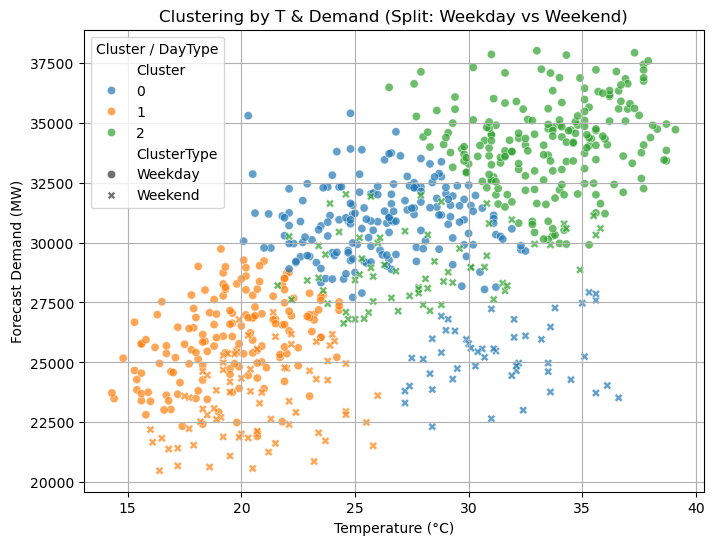

     Datetime     T    value  IsWeekend  Cluster
0  20250701 1  24.9  31178.3      False        0
1  20250701 2  25.4  29220.3      False        0
2  20250701 3  23.6  27816.3      False        1
3  20250701 4  23.2  26997.3      False        1
4  20250701 5  21.8  26562.8      False        1


In [5]:
# 결과를 저장할 리스트
results = []
df_merged = pd.merge(
    df_forecast[["Datetime", "value", "Weekday", "IsWeekend"]],
    df_weather[["Datetime", "T"]],
    on="Datetime", how="inner"
)
# 평일/주말 그룹 나눠서 반복
for weekend_flag, sub in df_merged.groupby("IsWeekend"):
    if sub.empty:
        continue
    
    # 스케일링 (T, value만)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(sub[["T", "value"]])
    
    # KMeans (예: 3개 클러스터)
    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(scaled)
    
    # 결과 저장
    sub = sub.copy()
    sub["Cluster"] = labels
    sub["ClusterType"] = "Weekend" if weekend_flag else "Weekday"
    results.append(sub)

# 합치기
df_clustered = pd.concat(results, ignore_index=True)

# ===== 시각화 =====
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_clustered, x="T", y="value",
    hue="Cluster", style="ClusterType", palette="tab10", alpha=0.7
)
plt.xlabel("Temperature (°C)")
plt.ylabel("Forecast Demand (MW)")
plt.title("Clustering by T & Demand (Split: Weekday vs Weekend)")
plt.legend(title="Cluster / DayType")
plt.grid(True)
plt.show()

# 확인
print(df_clustered[["Datetime", "T", "value", "IsWeekend", "Cluster"]].head())


클러스터링 확인: 주말

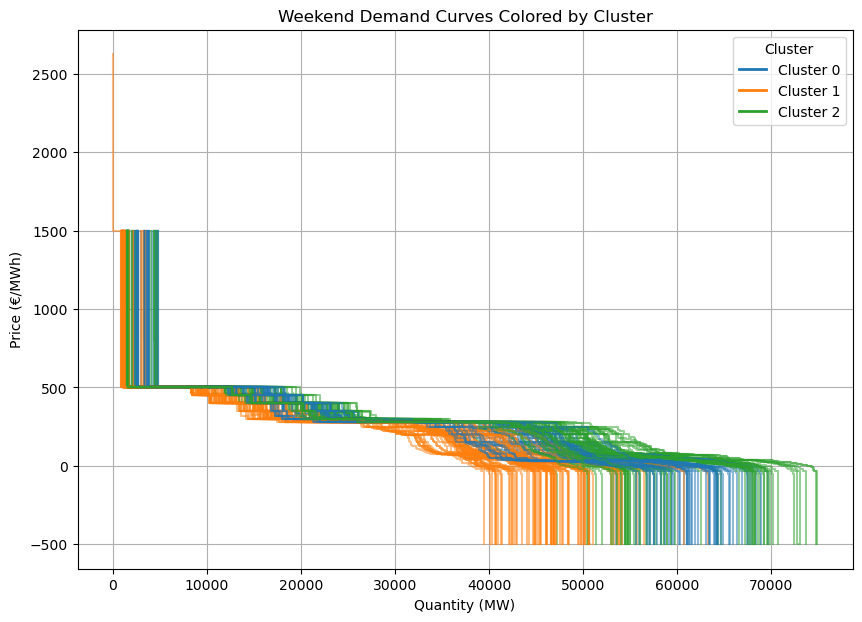

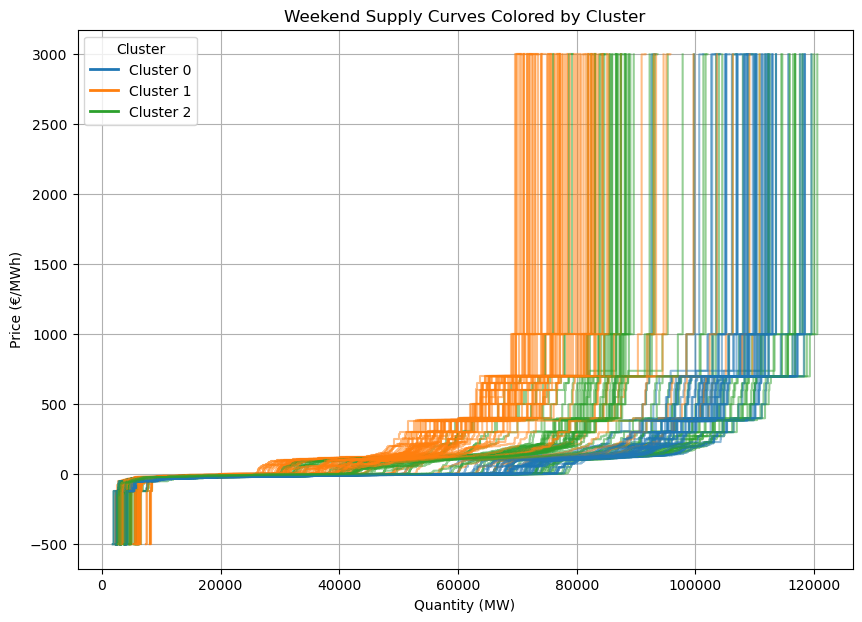

In [7]:
# 1. 요일/주말 여부 붙이기 (df_supply 기준)
df_supply["Weekday"] = df_supply["Date"].dt.weekday
df_supply["IsWeekend"] = df_supply["Weekday"].isin([5,6])

# 2. 주말 데이터만 선택
df_weekend = df_supply[df_supply["IsWeekend"]]

# 3. Cluster 라벨 붙이기 (Datetime 기준 merge)
df_weekend = df_weekend.merge(
    df_clustered[["Datetime","Cluster"]],
    on="Datetime", how="left"
)

# 4. 색상 팔레트 (클러스터 개수만큼)
clusters = sorted(df_weekend["Cluster"].dropna().unique())
palette = dict(zip(clusters, sns.color_palette("tab10", len(clusters))))

# ========================
# (A) 주말 수요곡선
# ========================
plt.figure(figsize=(10,7))

for dt in df_weekend["Datetime"].unique():
    sub = df_weekend[df_weekend["Datetime"]==dt]
    cluster = sub["Cluster"].iloc[0]   # 해당 시간의 클러스터
    
    # 수요곡선만 선택
    dem = sub[sub["GC"]=="C"]
    if dem.empty:
        continue
    
    d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]
    
    # 수요곡선: 클러스터 색상
    plt.step(d_agg["Cumul"], d_agg["Price"],
             where="post", color=palette[cluster], alpha=0.5)

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Weekend Demand Curves Colored by Cluster")
plt.grid(True)

# 범례
handles = [plt.Line2D([0],[0], color=palette[c], lw=2, label=f"Cluster {c}") for c in clusters]
plt.legend(handles=handles, title="Cluster")
plt.show()


# ========================
# (B) 주말 공급곡선
# ========================
plt.figure(figsize=(10,7))

for dt in df_weekend["Datetime"].unique():
    sub = df_weekend[df_weekend["Datetime"]==dt]
    cluster = sub["Cluster"].iloc[0]   # 해당 시간의 클러스터
    
    # 공급곡선만 선택
    sup = sub[sub["GC"]=="V"]
    if sup.empty:
        continue
    
    s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    s_agg["Cumul"] = s_agg["Amount"].cumsum()
    
    # 공급곡선: 클러스터 색상
    plt.step(s_agg["Cumul"], s_agg["Price"],
             where="post", color=palette[cluster], alpha=0.5)

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Weekend Supply Curves Colored by Cluster")
plt.grid(True)

# 범례
handles = [plt.Line2D([0],[0], color=palette[c], lw=2, label=f"Cluster {c}") for c in clusters]
plt.legend(handles=handles, title="Cluster")
plt.show()


클러스터링 확인: 평일

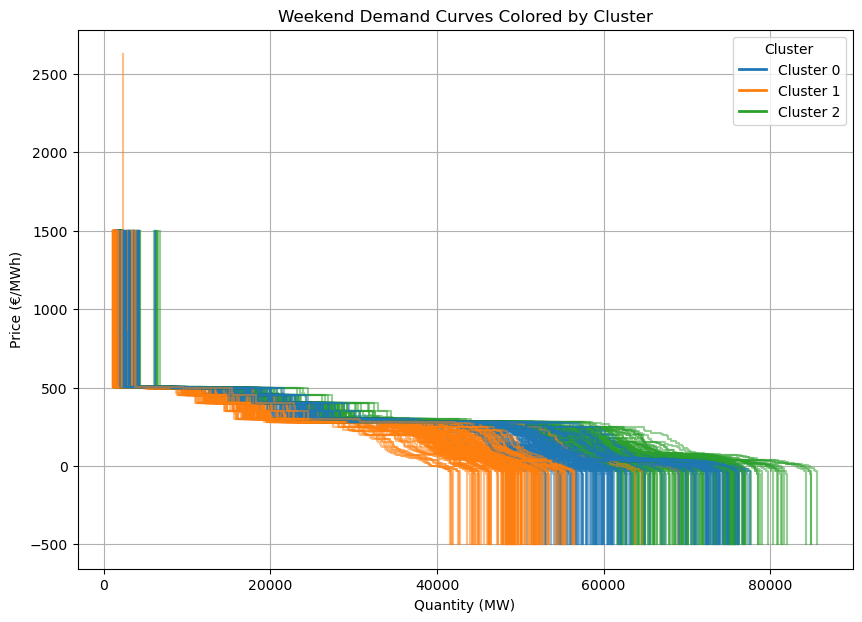

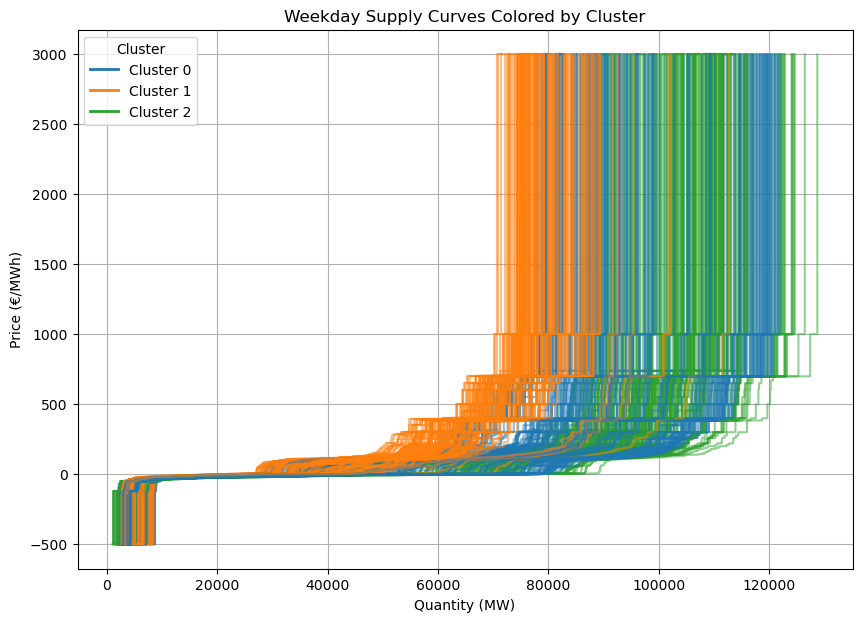

In [8]:
# 1. 요일/주말 여부 붙이기 (df_supply 기준)
df_supply["Weekday"] = df_supply["Date"].dt.weekday
df_supply["IsWeekend"] = df_supply["Weekday"].isin([5,6])

# 2. 주말 데이터만 선택
df_weekday = df_supply[~df_supply["IsWeekend"]]

# 3. Cluster 라벨 붙이기 (Datetime 기준 merge)
df_weekday = df_weekday.merge(
    df_clustered[["Datetime","Cluster"]],
    on="Datetime", how="left"
)

# 4. 색상 팔레트 (클러스터 개수만큼)
clusters = sorted(df_weekday["Cluster"].dropna().unique())
palette = dict(zip(clusters, sns.color_palette("tab10", len(clusters))))

# ========================
# (A) 주말 수요곡선
# ========================
plt.figure(figsize=(10,7))

for dt in df_weekday["Datetime"].unique():
    sub = df_weekday[df_weekday["Datetime"]==dt]
    cluster = sub["Cluster"].iloc[0]   # 해당 시간의 클러스터
    
    # 수요곡선만 선택
    dem = sub[sub["GC"]=="C"]
    if dem.empty:
        continue
    
    d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]
    
    # 수요곡선: 클러스터 색상
    plt.step(d_agg["Cumul"], d_agg["Price"],
             where="post", color=palette[cluster], alpha=0.5)

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Weekend Demand Curves Colored by Cluster")
plt.grid(True)

# 범례
handles = [plt.Line2D([0],[0], color=palette[c], lw=2, label=f"Cluster {c}") for c in clusters]
plt.legend(handles=handles, title="Cluster")
plt.show()


# ========================
# (B) 주말 공급곡선
# ========================
plt.figure(figsize=(10,7))

for dt in df_weekday["Datetime"].unique():
    sub = df_weekday[df_weekday["Datetime"]==dt]
    cluster = sub["Cluster"].iloc[0]   # 해당 시간의 클러스터
    
    # 공급곡선만 선택
    sup = sub[sub["GC"]=="V"]
    if sup.empty:
        continue
    
    s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    s_agg["Cumul"] = s_agg["Amount"].cumsum()
    
    # 공급곡선: 클러스터 색상
    plt.step(s_agg["Cumul"], s_agg["Price"],
             where="post", color=palette[cluster], alpha=0.5)

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Weekday Supply Curves Colored by Cluster")
plt.grid(True)

# 범례
handles = [plt.Line2D([0],[0], color=palette[c], lw=2, label=f"Cluster {c}") for c in clusters]
plt.legend(handles=handles, title="Cluster")
plt.show()

수요 공급곡선 데이터 추출 및 클러스터 레이블링

In [9]:
supply_curves = []

for (dt, cluster), sub in df_supply.merge(
    df_clustered[["Datetime", "Cluster"]], on="Datetime", how="left"
).groupby(["Datetime", "Cluster"]):
    
    sup = sub[sub["GC"] == "V"].copy()   # 공급
    dem = sub[sub["GC"] == "C"].copy()   # 수요
    
    if sup.empty or dem.empty:
        continue
    
    # 공급곡선 집계
    s_agg = (sup.groupby("Price")["Amount"]
                .sum().reset_index()
                .sort_values("Price"))
    s_agg["Cumul"] = s_agg["Amount"].cumsum()
    
    # 수요곡선 집계
    d_agg = (dem.groupby("Price")["Amount"]
                .sum().reset_index()
                .sort_values("Price"))
    d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]
    
    # Date, Hour, Weekend 여부 계산
    date_str, hour_str = dt.split()
    date_dt = pd.to_datetime(date_str, format="%Y%m%d")
    is_weekend = date_dt.weekday() in [5,6]
    
    supply_curves.append({
        "Datetime": dt,
        "Date": date_dt,
        "Hour": int(hour_str),
        "Cluster": cluster,
        "IsWeekend": is_weekend,
        "Supply": s_agg,
        "Demand": d_agg
    })

print(f"총 {len(supply_curves)} 개의 수요/공급곡선 쌍이 생성되었습니다.")
print(supply_curves[0].keys())  # 구조 확인

총 696 개의 수요/공급곡선 쌍이 생성되었습니다.
dict_keys(['Datetime', 'Date', 'Hour', 'Cluster', 'IsWeekend', 'Supply', 'Demand'])


## 클러스터링별 분포 추정

함수 정의

In [15]:
quantiles = [0.4, 0.45, 0.5, 0.55, 0.6]
bw = 0.2

In [16]:
def kde_quantile_supply_curves(cluster_curves, q_grid, bw=0.2, quantiles=quantiles):
    """공급: 여러 분위수 기반 곡선 반환"""
    all_q, all_p = [], []
    for c in cluster_curves:
        s = c["Supply"]
        all_q.extend(s["Cumul"].values)
        all_p.extend(s["Price"].values)
    if not all_q:
        return {}

    vals = np.vstack([all_q, all_p])
    kde  = gaussian_kde(vals, bw_method=bw)

    pmin, pmax = np.nanmin(all_p), np.nanmax(all_p)
    p_axis = np.linspace(pmin, pmax, 400)

    curves = {}
    for qtile in quantiles:
        curve = []
        for q in q_grid:
            pts = np.vstack([np.full_like(p_axis, q), p_axis])
            dens = kde(pts)
            cdf = np.cumsum(dens) / np.sum(dens)
            curve.append(np.interp(qtile, cdf, p_axis))
        curves[qtile] = np.array(curve)
    return curves
# 수요 quantile curves (joint KDE에서 Q→P 분위수)
def kde_quantile_demand_curves(cluster_curves, q_grid, bw=0.2, quantiles=quantiles):
    all_q, all_p = [], []
    for c in cluster_curves:
        d = c["Demand"]
        all_q.extend(d["Cumul"].values)
        all_p.extend(d["Price"].values)
    if not all_q:
        return None
    
    vals = np.vstack([all_q, all_p])
    kde  = gaussian_kde(vals, bw_method=bw)

    pmin, pmax = np.nanmin(all_p), np.nanmax(all_p)
    p_axis = np.linspace(pmin, pmax, 400)

    curves = {}
    for q in q_grid:
        pts = np.vstack([np.full_like(p_axis, q), p_axis])
        dens = kde(pts)
        cdf = np.cumsum(dens) / np.sum(dens)
        for qtile in quantiles:
            p_q = np.interp(qtile, cdf, p_axis)
            curves.setdefault(qtile, []).append(p_q)
    
    return {qtile: np.array(p_list) for qtile, p_list in curves.items()}

### 분포 추출

In [17]:
# 너가 쓰던 그리드 그대로 사용
q_grid = np.linspace(20000, 80000, 300)   # Q 축
wf_offer_grid = np.arange(0, 5000, 10)

# 혹시 label 키가 'Cluster'가 아닌 'TCluster'로 붙어있을 수도 있어서 안전장치
CLUSTER_KEY = "Cluster" if all((CLUSTER_KEY in sc) if (CLUSTER_KEY:="Cluster") else False for sc in supply_curves) else "TCluster"

# (daytype, cluster) → members
groups = defaultdict(lambda: defaultdict(list))
for cur in supply_curves:
    daytype = "Weekend" if cur.get("IsWeekend", False) else "Weekday"
    cl = cur.get(CLUSTER_KEY, None)
    if cl is None:
        continue
    groups[daytype][cl].append(cur)

# 캐시: {daytype: {cluster: {"q_grid":..., "sup_curves":{qt:curve}, "dem_curves":{qt:curve}}}}
kde_cache = {"Weekend": {}, "Weekday": {}}

for daytype, cluster_dict in groups.items():
    for c, members in cluster_dict.items():
        if not members:
            print(f"[{daytype} | Cluster {c}] skip (no members)")
            continue

        print(f"\n[{daytype} | Cluster {c}] members: {len(members)}")

        # KDE 추정
        sup_curves = kde_quantile_supply_curves(
            members, q_grid, bw=bw, quantiles=quantiles
        )
        dem_curves = kde_quantile_demand_curves(
            members, q_grid, bw=bw, quantiles=quantiles
        )

        if not sup_curves or not dem_curves:
            print(f"  → skip (no curves)")
            continue

        # 캐시에 저장
        kde_cache[daytype][c] = {
            "q_grid": q_grid.copy(),
            "sup_curves": {qt: curve.copy() for qt, curve in sup_curves.items()},
            "dem_curves": {qt: curve.copy() for qt, curve in dem_curves.items()},
        }

        # 디버그 출력: 각 분위수별 곡선 길이
        for qt, curve in sup_curves.items():
            print(f"  Supply Q{int(qt*100)}: {len(curve)} points")
        for qt, curve in dem_curves.items():
            print(f"  Demand Q{int(qt*100)}: {len(curve)} points")

print("\nFinal KDE cache keys:", {k: list(v.keys()) for k,v in kde_cache.items()})



[Weekday | Cluster 0] members: 165
  Supply Q40: 300 points
  Supply Q45: 300 points
  Supply Q50: 300 points
  Supply Q55: 300 points
  Supply Q60: 300 points
  Demand Q40: 300 points
  Demand Q45: 300 points
  Demand Q50: 300 points
  Demand Q55: 300 points
  Demand Q60: 300 points

[Weekday | Cluster 2] members: 194
  Supply Q40: 300 points
  Supply Q45: 300 points
  Supply Q50: 300 points
  Supply Q55: 300 points
  Supply Q60: 300 points
  Demand Q40: 300 points
  Demand Q45: 300 points
  Demand Q50: 300 points
  Demand Q55: 300 points
  Demand Q60: 300 points

[Weekday | Cluster 1] members: 145
  Supply Q40: 300 points
  Supply Q45: 300 points
  Supply Q50: 300 points
  Supply Q55: 300 points
  Supply Q60: 300 points
  Demand Q40: 300 points
  Demand Q45: 300 points
  Demand Q50: 300 points
  Demand Q55: 300 points
  Demand Q60: 300 points

[Weekend | Cluster 2] members: 69
  Supply Q40: 300 points
  Supply Q45: 300 points
  Supply Q50: 300 points
  Supply Q55: 300 points
  Suppl

In [18]:
def kde_cache_to_long_df(kde_cache: dict) -> pd.DataFrame:
    """
    kde_cache 구조:
    {
      "Weekend": {
        c: {
          "q_grid": np.array([...]),
          "sup_curves": {0.1: np.array([...]), 0.3: ..., ...},
          "dem_curves": {0.1: np.array([...]), ...}
        },
        ...
      },
      "Weekday": { ... }
    }
    를 long DF로 변환: [daytype, cluster, side, quantile, q, p]
    """
    rows = []
    for daytype, clusters in kde_cache.items():
        for c, bundle in clusters.items():
            q_grid = bundle["q_grid"]
            # supply
            for qt, p_curve in bundle["sup_curves"].items():
                rows.extend([ (daytype, c, "supply", float(qt), float(q), float(p))
                              for q, p in zip(q_grid, p_curve) ])
            # demand
            for qt, p_curve in bundle["dem_curves"].items():
                rows.extend([ (daytype, c, "demand", float(qt), float(q), float(p))
                              for q, p in zip(q_grid, p_curve) ])
    return pd.DataFrame(rows, columns=["daytype","cluster","side","quantile","q","p"])

# 사용: 위에서 만든 kde_cache를 DF로 바꿔 CSV 저장
df_curves = kde_cache_to_long_df(kde_cache)
df_curves.to_csv("kde_curves0910.csv", index=False, encoding="utf-8-sig")
print("Saved:", "kde_curves0910.csv", "rows:", len(df_curves))

Saved: kde_curves0910.csv rows: 18000


### 테스트해보기

In [19]:
files = ["test_filteredcurve_20250730.csv", "test_filteredcurve_20250731.csv"]
test_list = []
for fn in files:
    tmp = pd.read_csv(fn, encoding="utf-8-sig")

    # 파일명에서 날짜 추출
    date_str = fn.split("_")[-1].split(".")[0]   # e.g., "20250730"
    tmp["Date"] = pd.to_datetime(date_str, format="%Y%m%d")

    # 공급곡선의 Period → Hour 변환 (1~24 → 1~24)
    tmp = tmp.dropna(subset=["Time Period"])
    tmp["Hour"] = tmp["Time Period"].astype(int)

    # Datetime: "20250730 1" 형태
    tmp["Datetime"] = tmp["Date"].dt.strftime("%Y%m%d") + " " + tmp["Hour"].astype(str)

    test_list.append(tmp)

df_test_supply = pd.concat(test_list, ignore_index=True)

In [ ]:
lab = df_clustered[["Datetime","IsWeekend","Cluster"]].dropna().copy()

isweek_map = dict(zip(lab["Datetime"], lab["IsWeekend"]))
tclust_map = dict(zip(lab["Datetime"], lab["Cluster"]))

# supply_curves 각 원소에 새 라벨 달기
for cur in supply_curves:
    dt = cur["Datetime"]
    cur["IsWeekend"] = bool(isweek_map.get(dt, False))
    cur["TCluster"]  = tclust_map.get(dt, None)

In [25]:
# 1. 테스트 feature 불러오기 (30, 31일)
df_test_features = pd.merge(
    df_forecast[["Datetime","value","Weekday","IsWeekend"]],
    df_weather[["Datetime","T"]],
    on="Datetime", how="inner"
)
df_test_features = df_test_features[df_test_features["Datetime"].isin(df_test_supply["Datetime"].unique())]

# 2. 클러스터링 모델 다시 나누기 (주말/평일)
kmeans_models = {}
scalers = {}

for weekend_flag, sub in df_clustered.groupby("IsWeekend"):
    if sub.empty: continue
    scaler = StandardScaler()
    X = scaler.fit_transform(sub[["T", "value"]]) 
    kmeans = KMeans(n_clusters=sub["Cluster"].nunique(), random_state=42)
    kmeans.fit(X)
    key = "Weekend" if weekend_flag else "Weekday"
    kmeans_models[key] = kmeans
    scalers[key] = scaler

# 3. 테스트 feature에 클러스터 라벨 붙이기
labels = []
for _, row in df_test_features.iterrows():
    key = "Weekend" if row["IsWeekend"] else "Weekday"
    scaler = scalers[key]
    kmeans = kmeans_models[key]
    X_test = scaler.transform([[row["T"], row["value"]]])
    cluster = kmeans.predict(X_test)[0]
    labels.append(cluster)

df_test_features["TCluster"] = labels

print(df_test_features[["Datetime","T","value","IsWeekend","TCluster"]])

        Datetime     T    value  IsWeekend  TCluster
696   20250730 1  20.6  26945.0      False         1
697   20250730 2  19.3  25405.5      False         1
698   20250730 3  18.3  24266.3      False         1
699   20250730 4  17.2  23671.3      False         1
700   20250730 5  16.8  23400.8      False         1
701   20250730 6  15.9  23753.0      False         1
702   20250730 7  15.8  25944.3      False         1
703   20250730 8  18.4  28016.0      False         1
704   20250730 9  22.4  29209.8      False         0
705  20250730 10  24.2  29590.8      False         0
706  20250730 11  25.7  29846.0      False         0
707  20250730 12  28.1  30070.0      False         0
708  20250730 13  30.0  30380.0      False         0
709  20250730 14  31.1  30809.3      False         0
710  20250730 15  32.8  30751.3      False         2
711  20250730 16  33.3  30146.0      False         2
712  20250730 17  34.0  29962.8      False         2
713  20250730 18  33.8  30312.0      False    

c:\Users\symply_jina\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\symply_jina\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\symply_jina\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\symply_jina\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\symply_jina\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Us

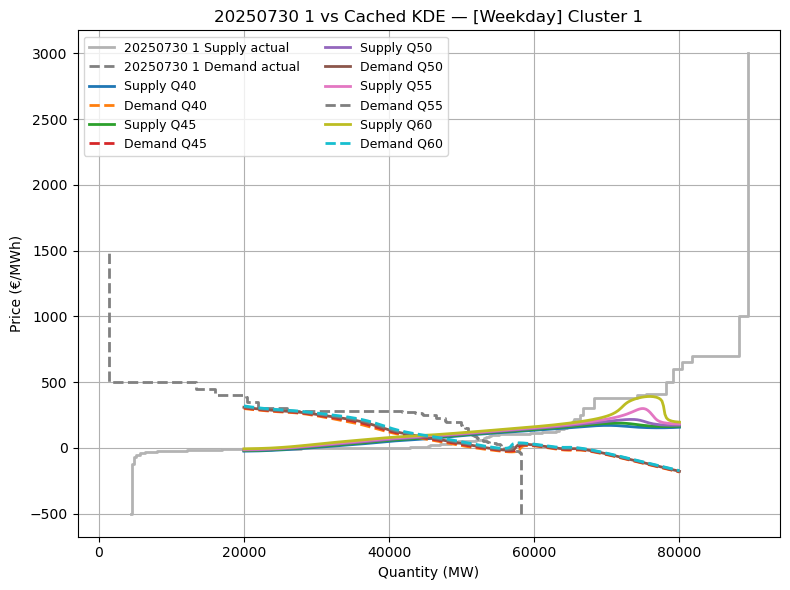

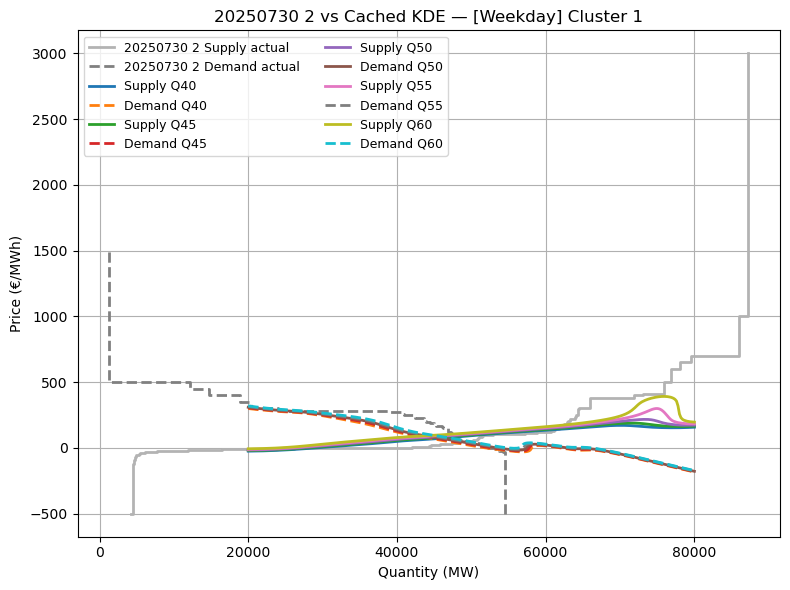

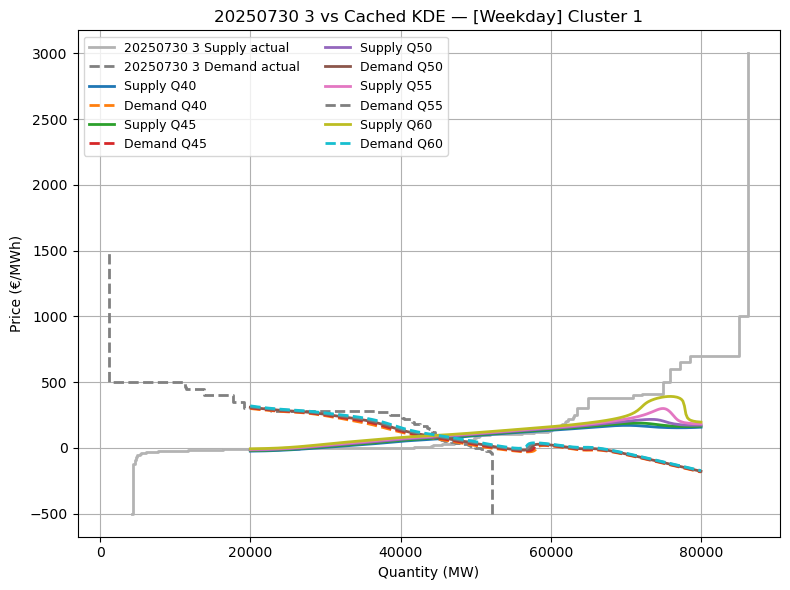

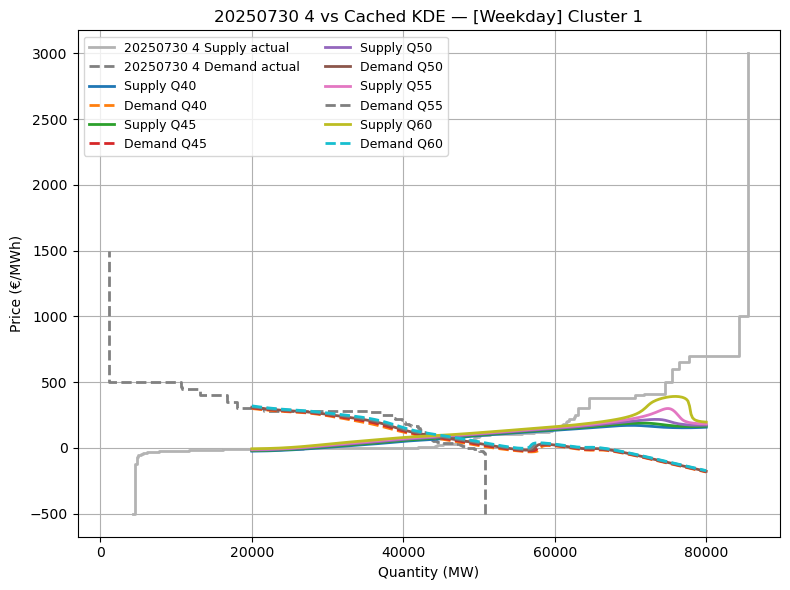

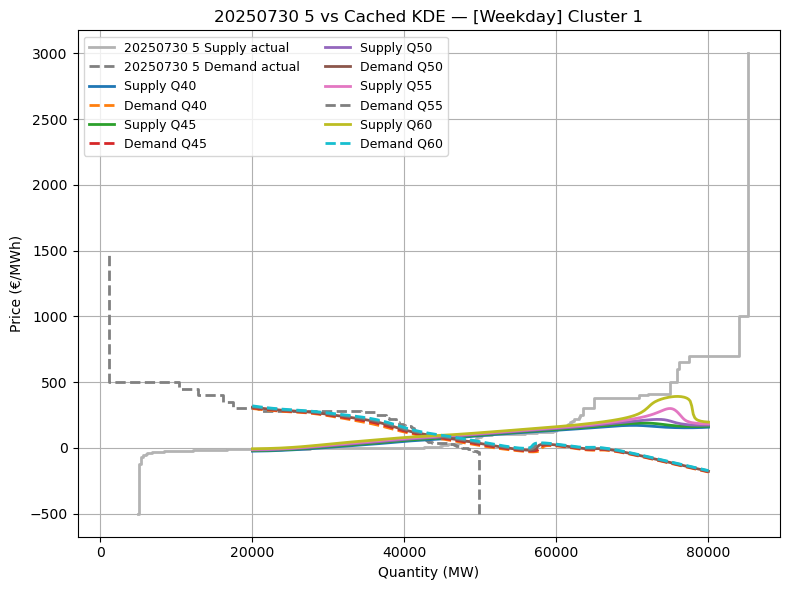

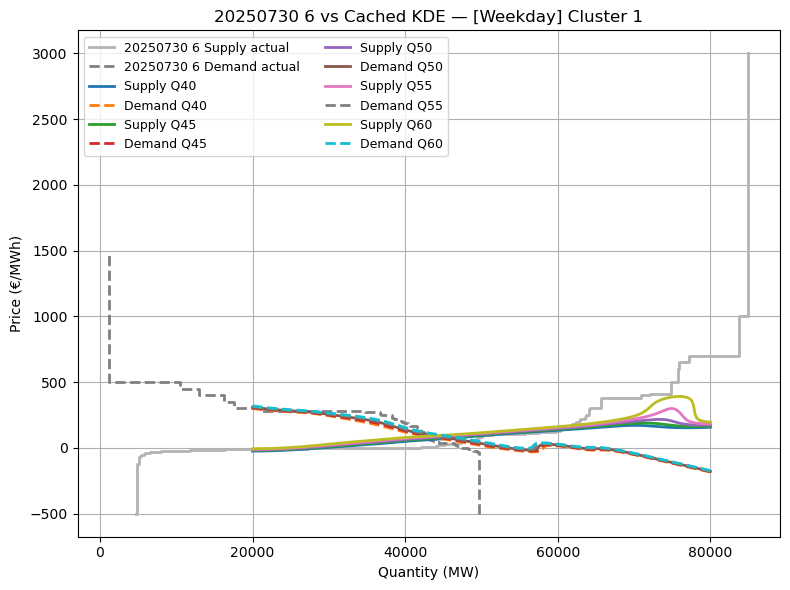

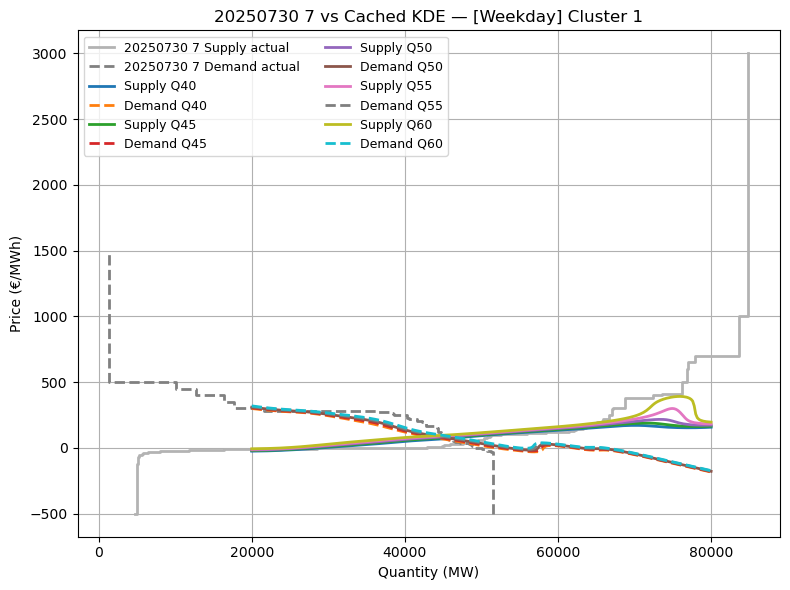

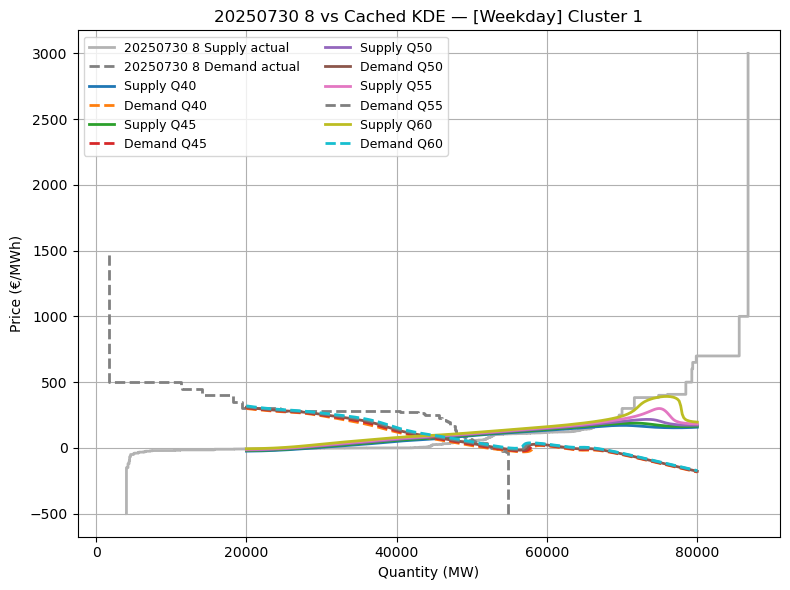

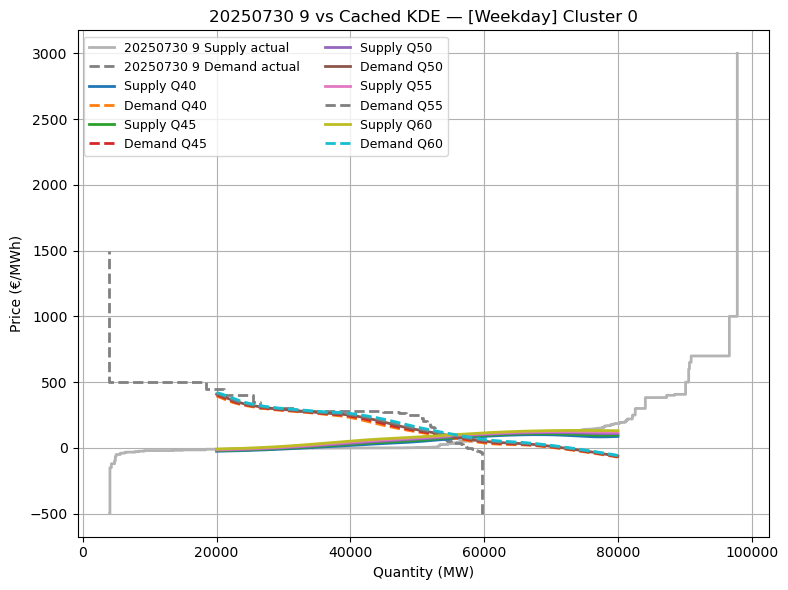

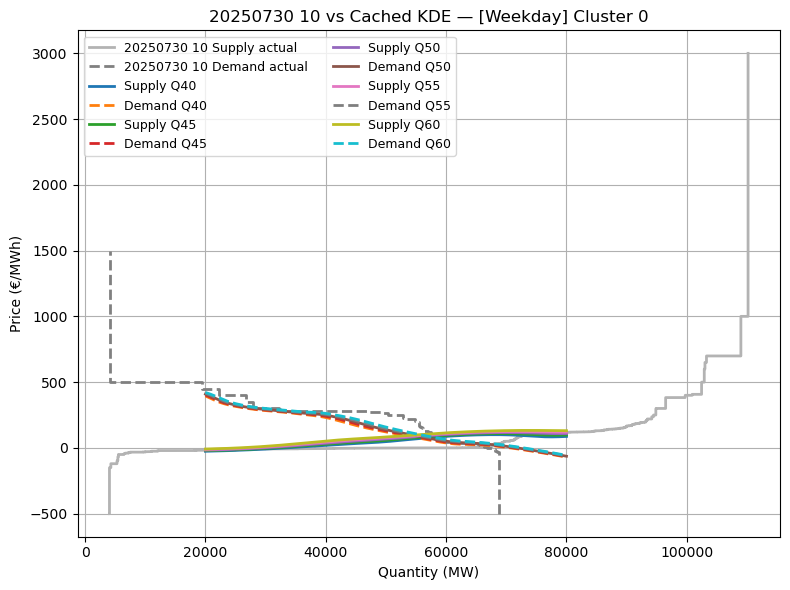

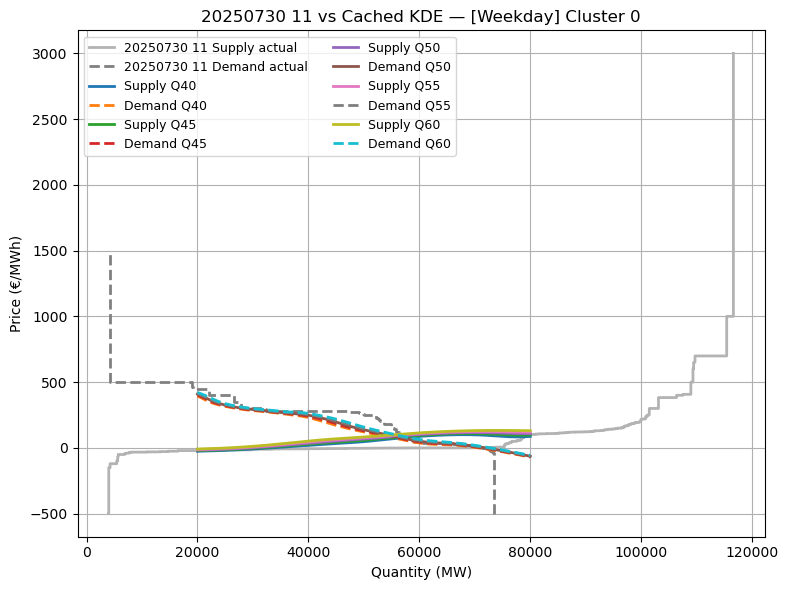

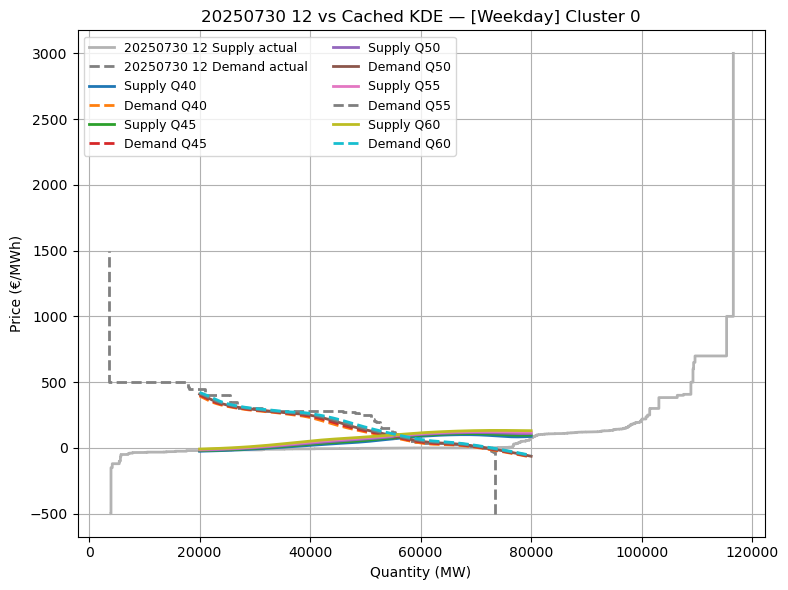

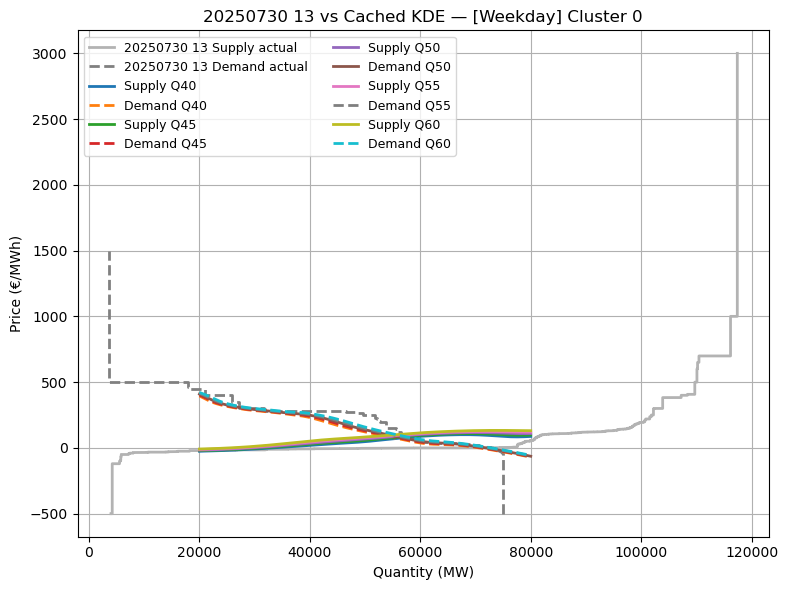

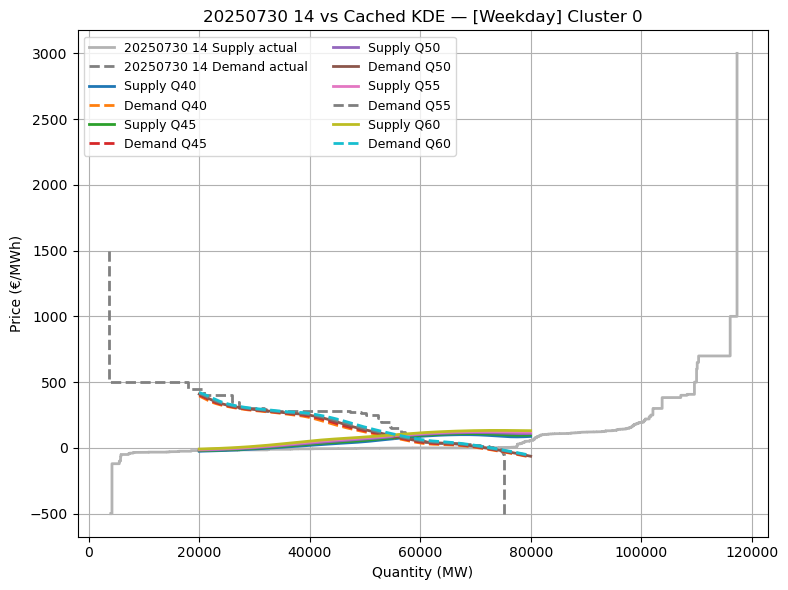

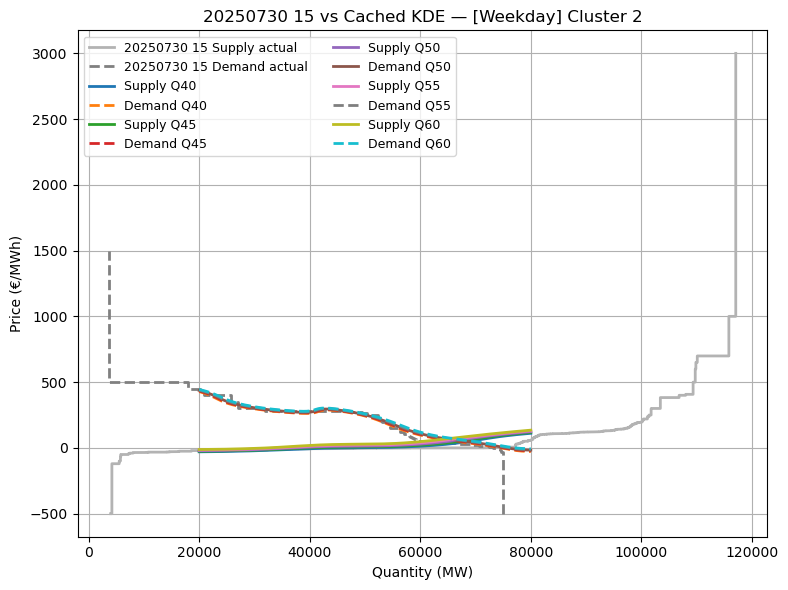

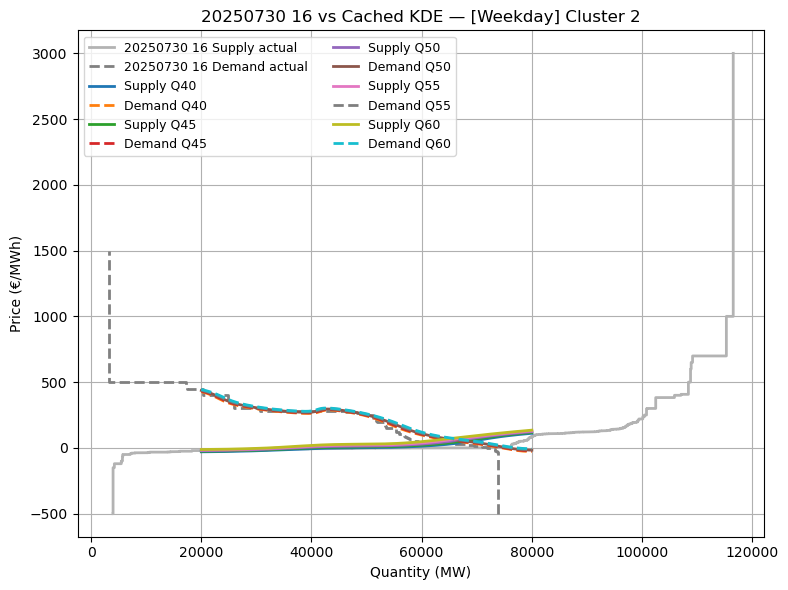

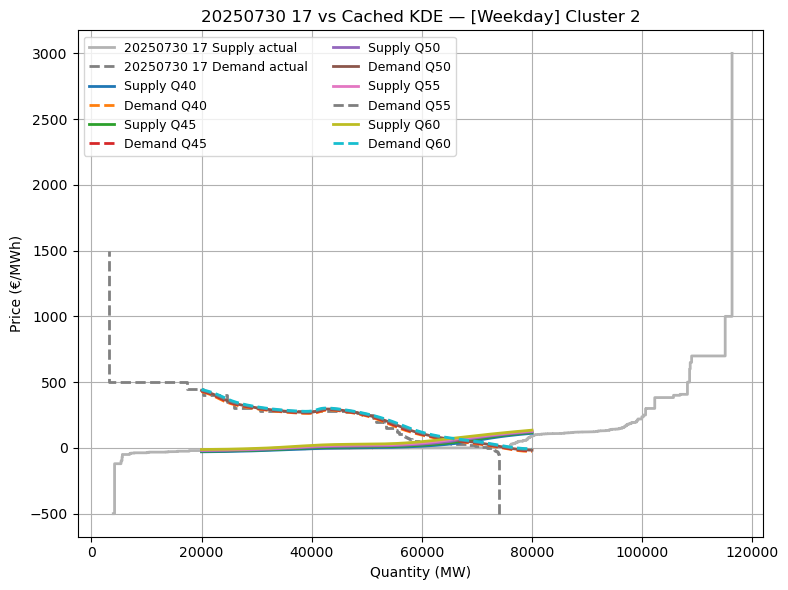

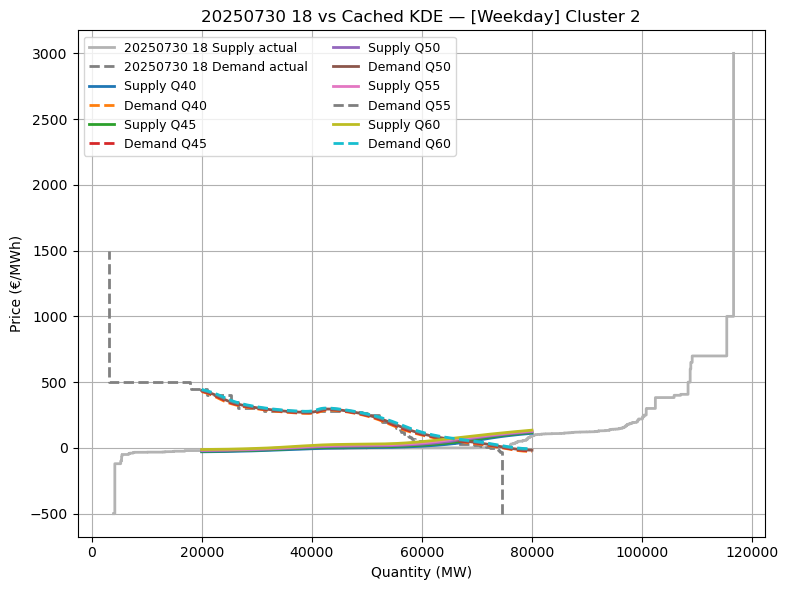

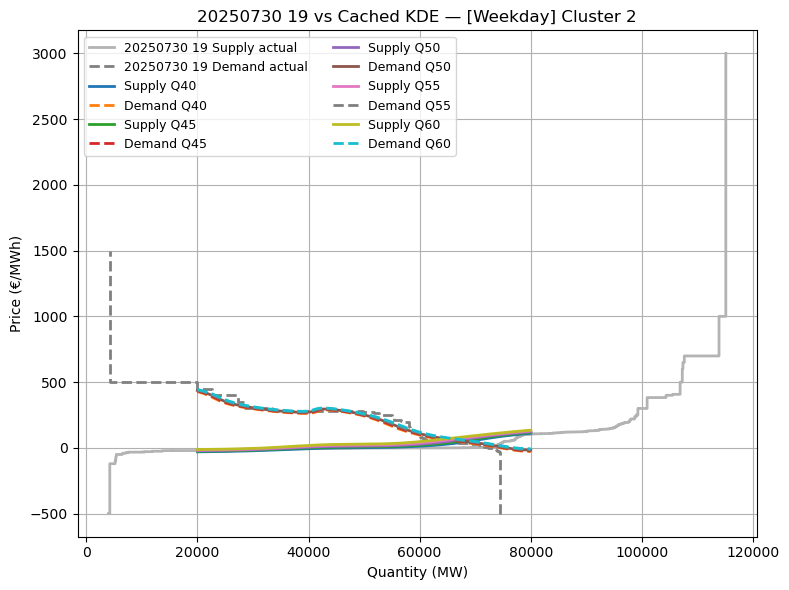

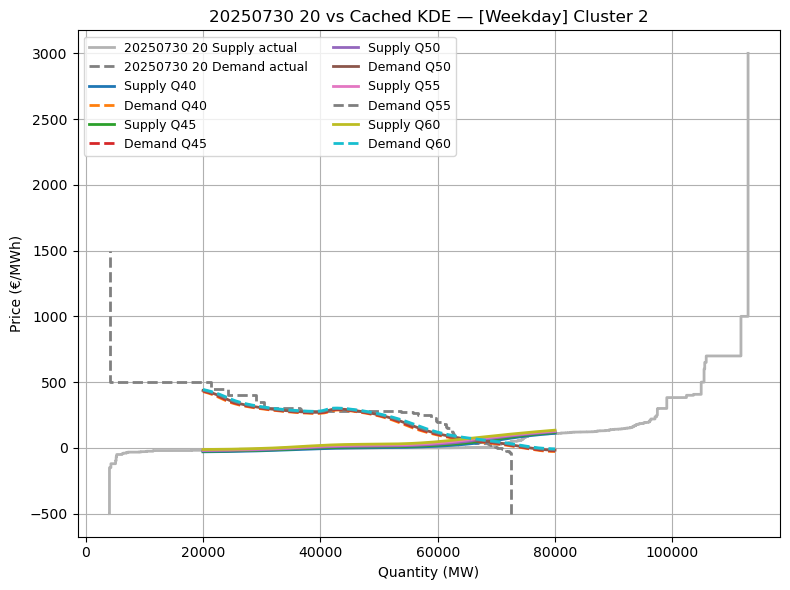

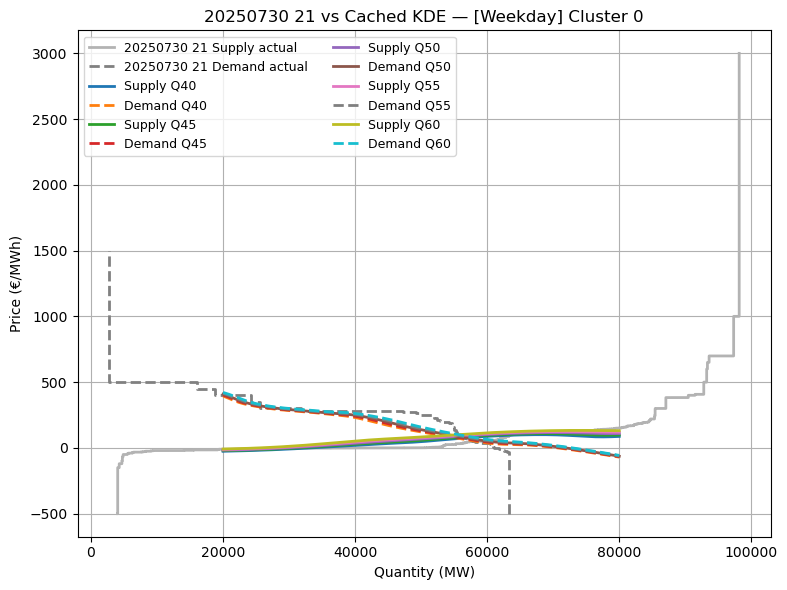

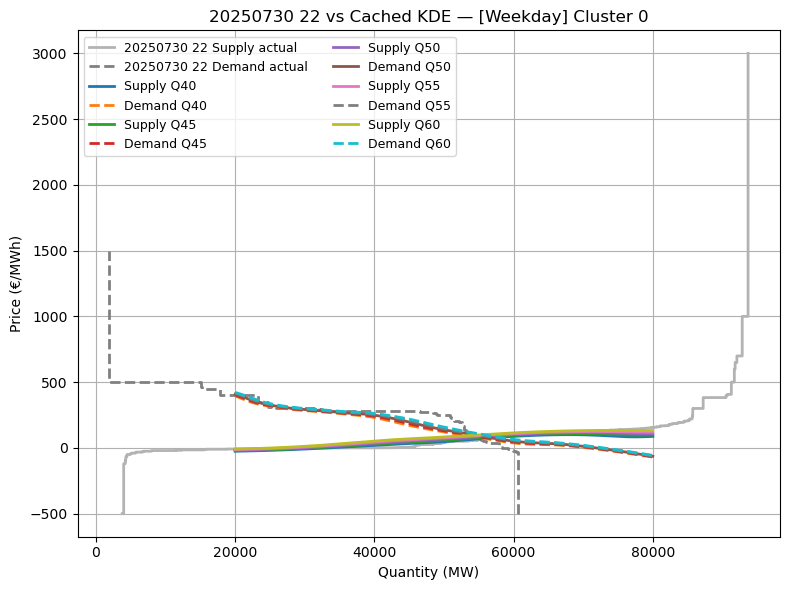

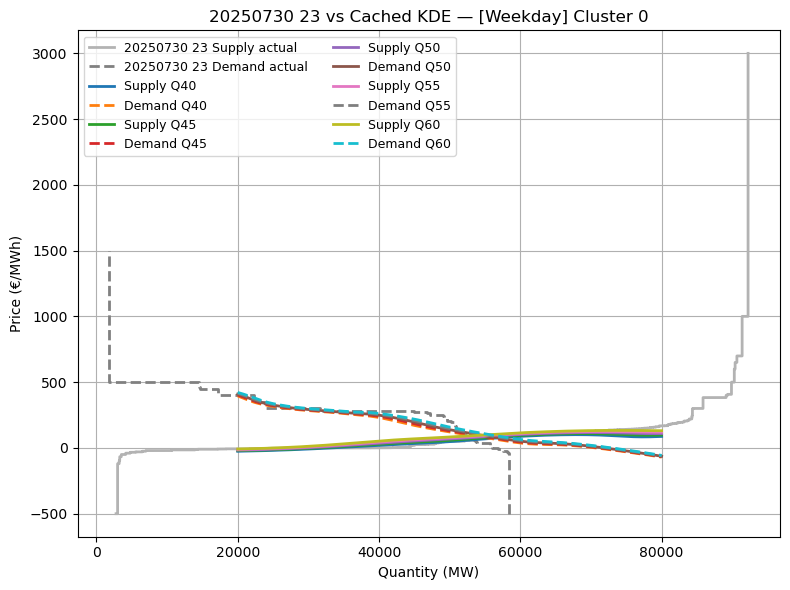

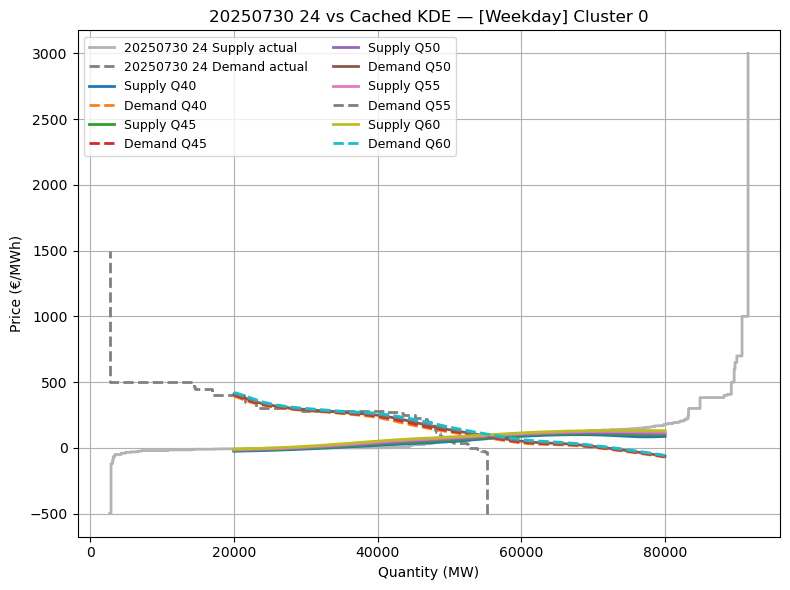

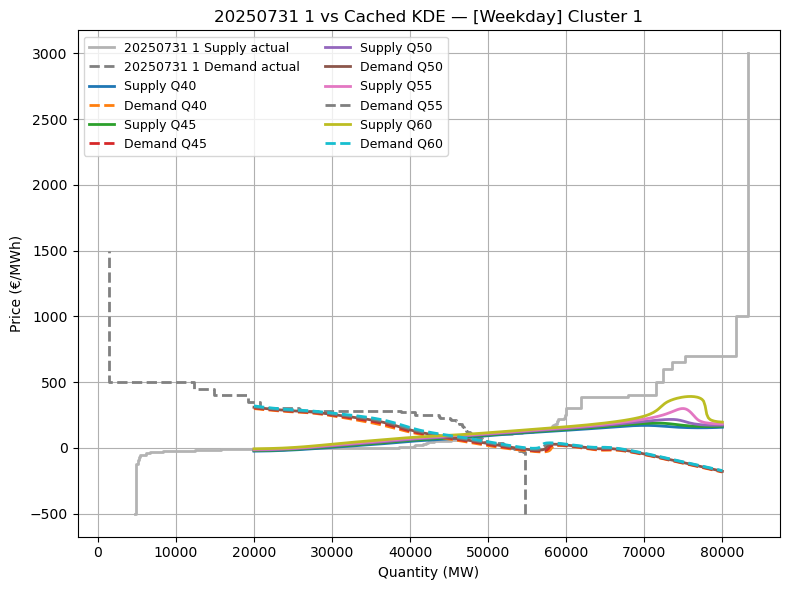

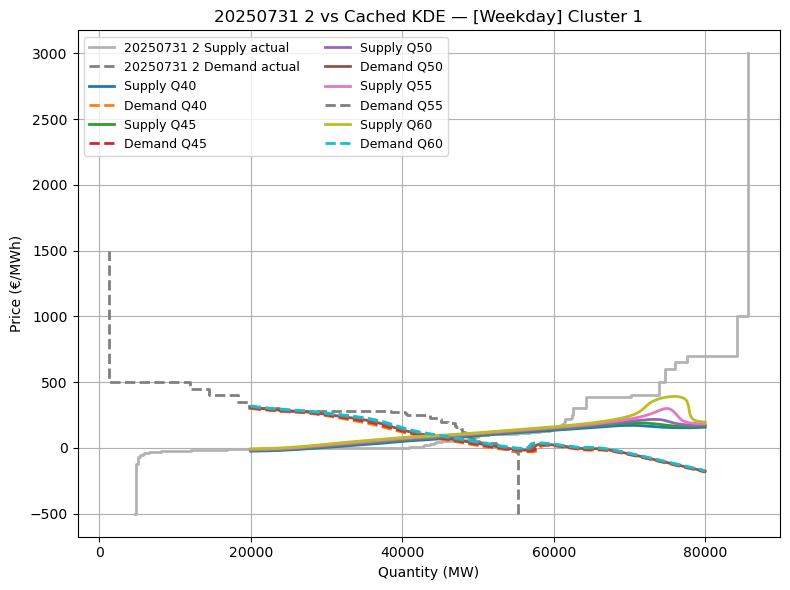

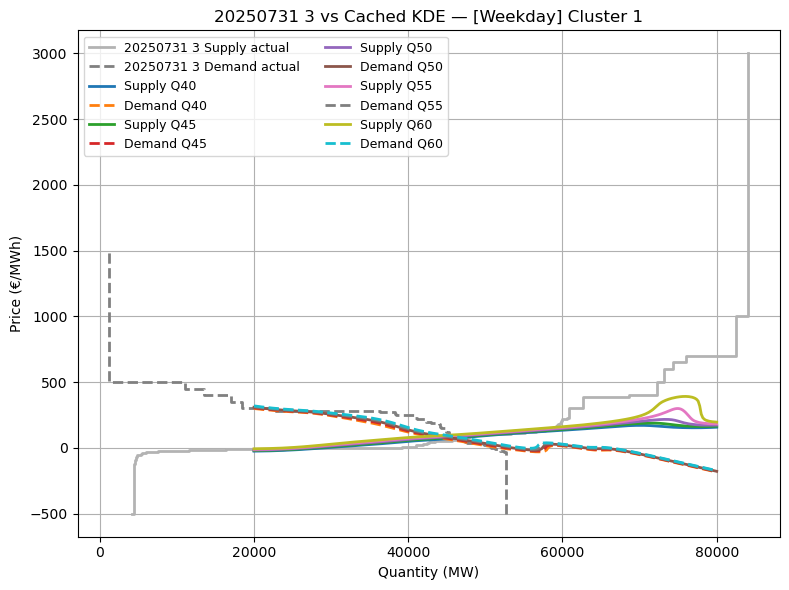

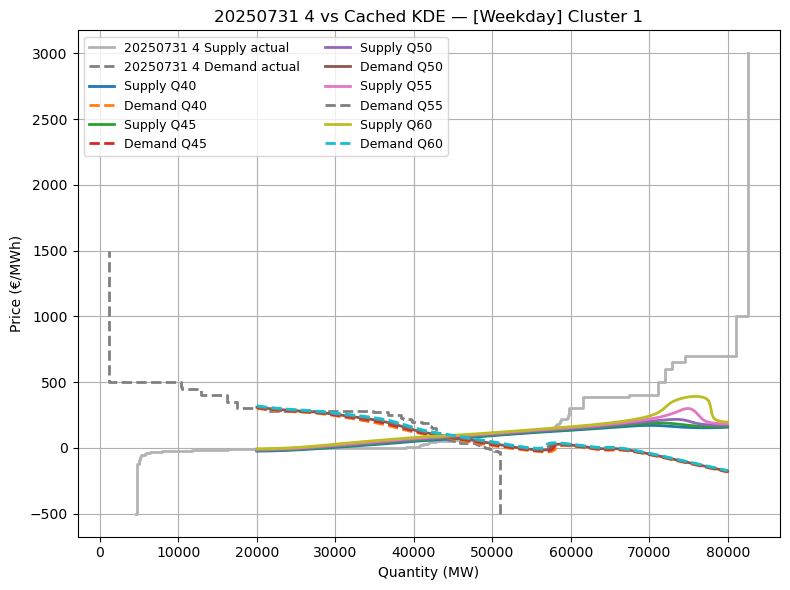

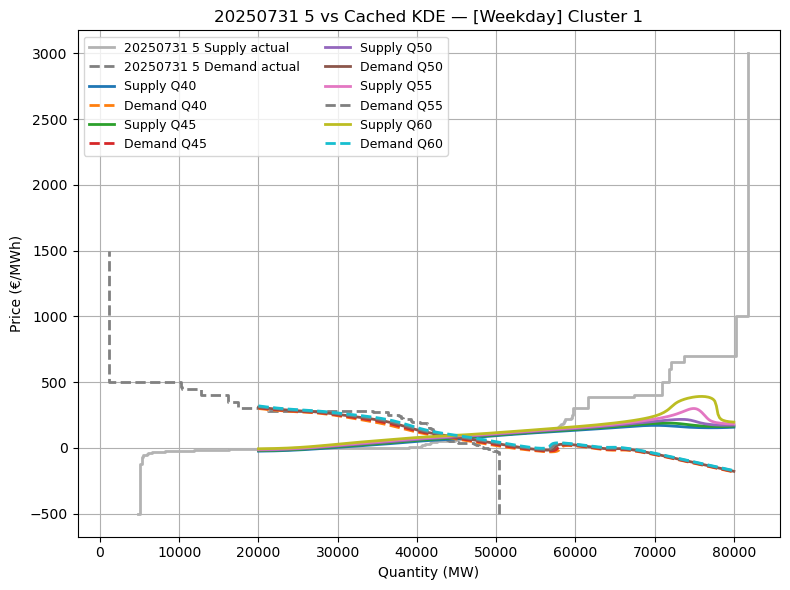

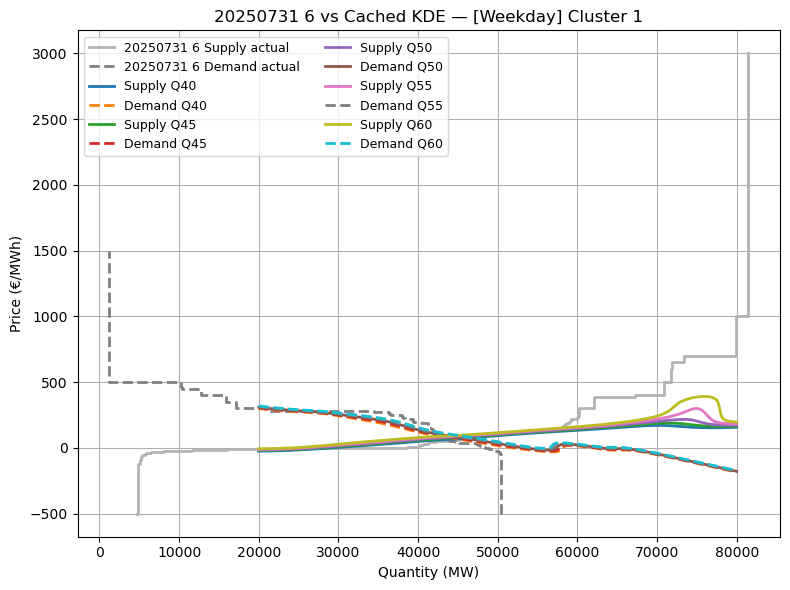

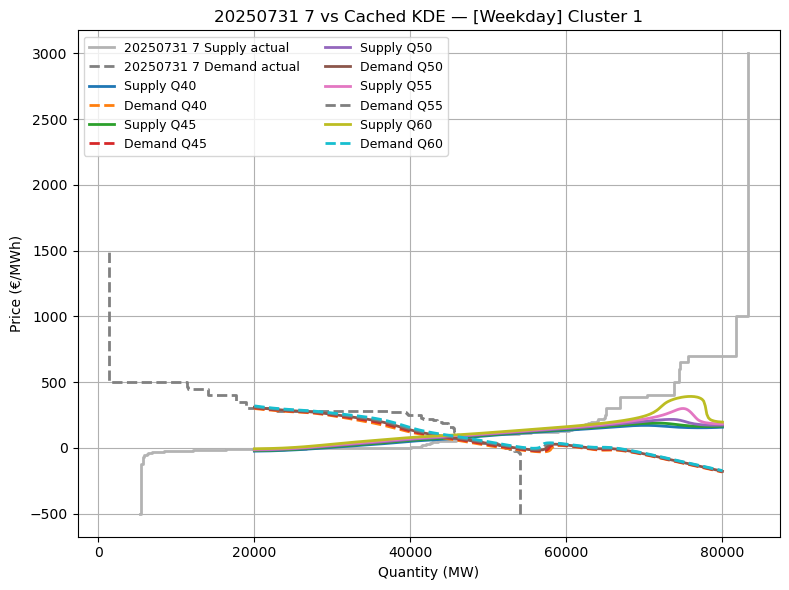

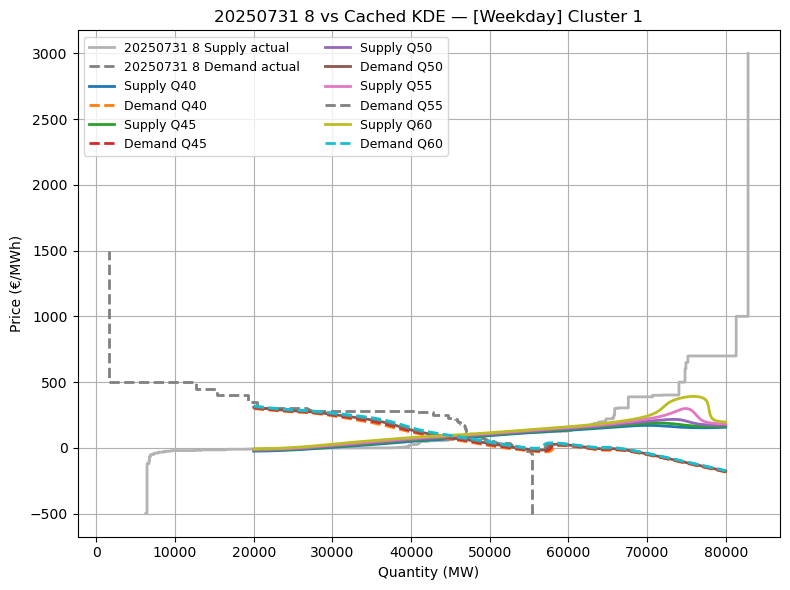

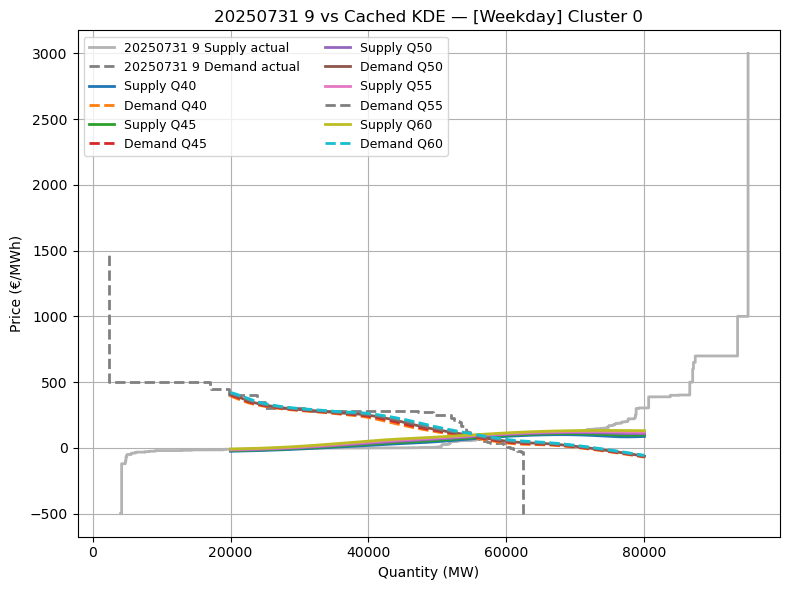

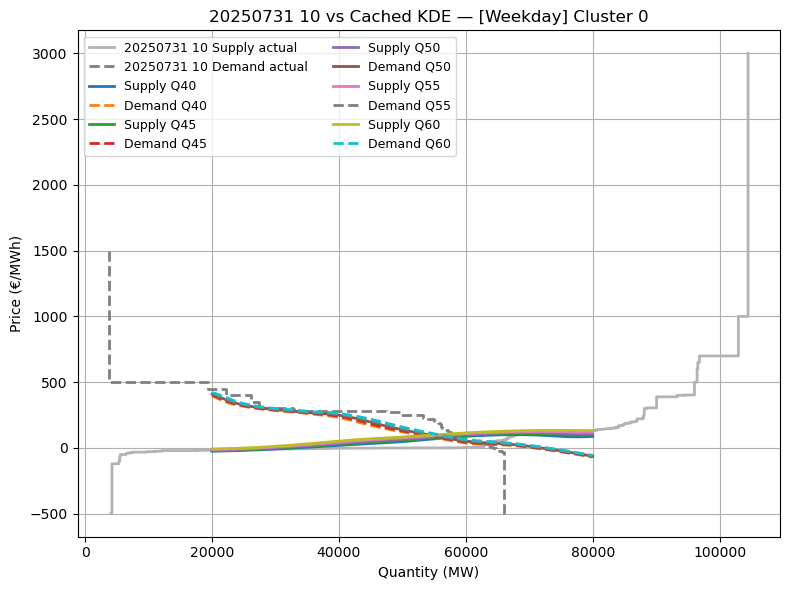

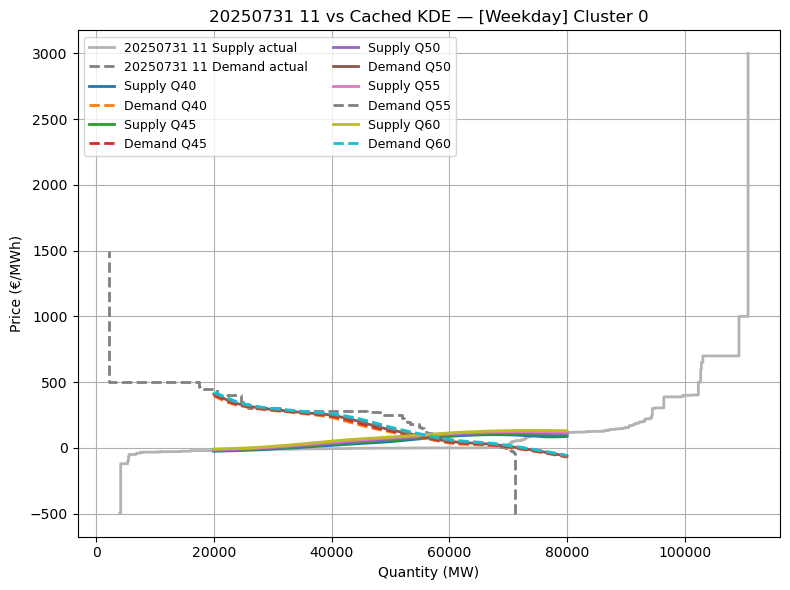

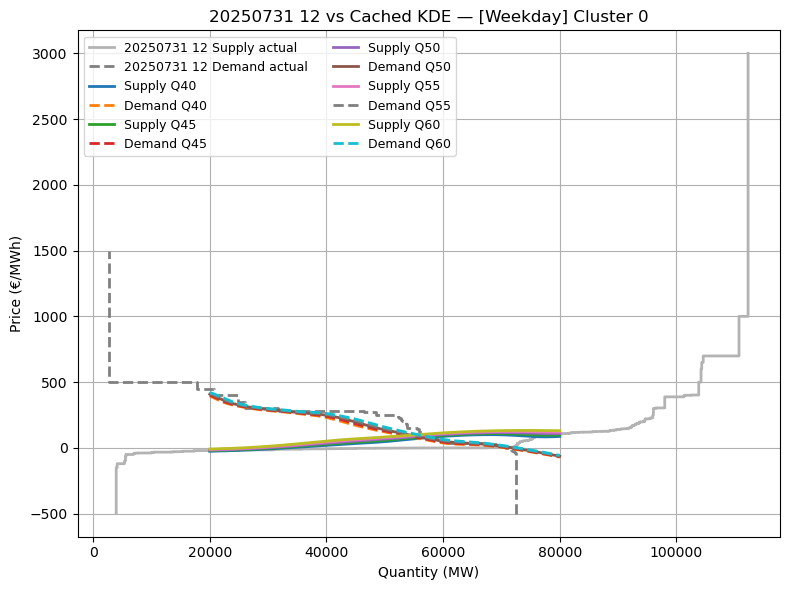

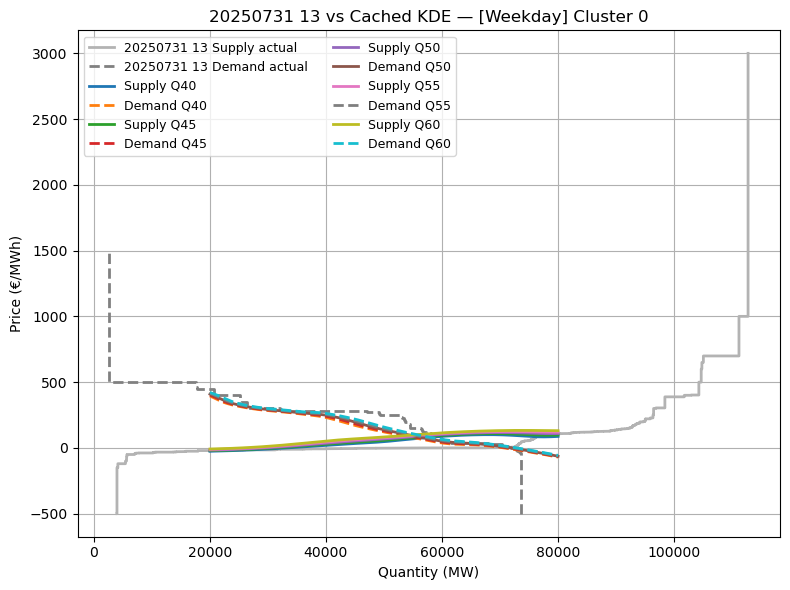

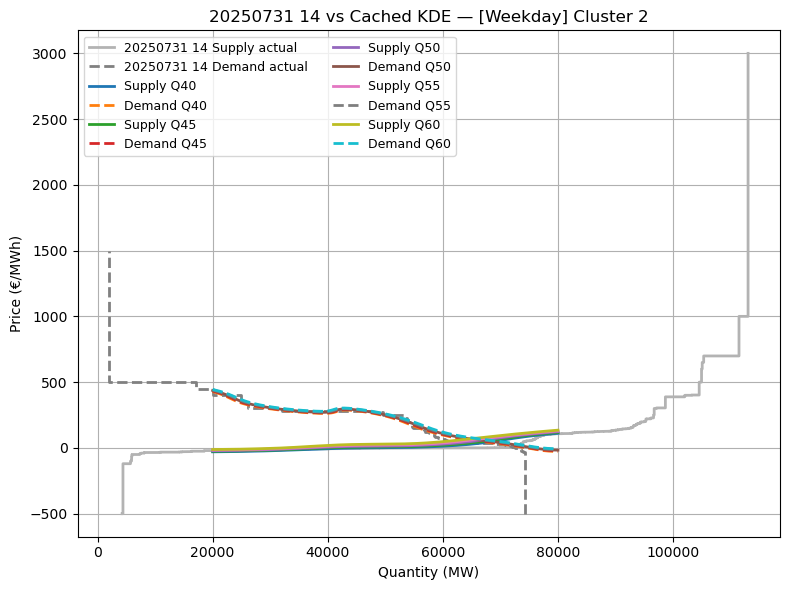

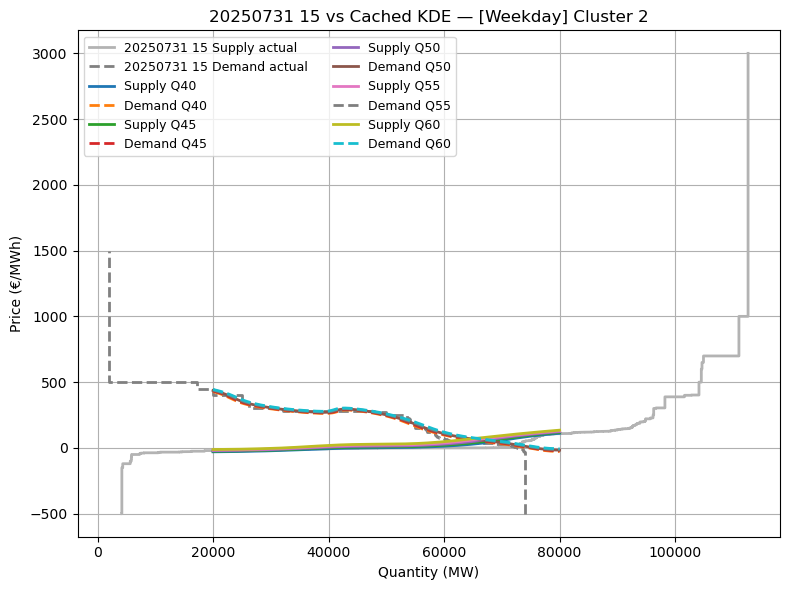

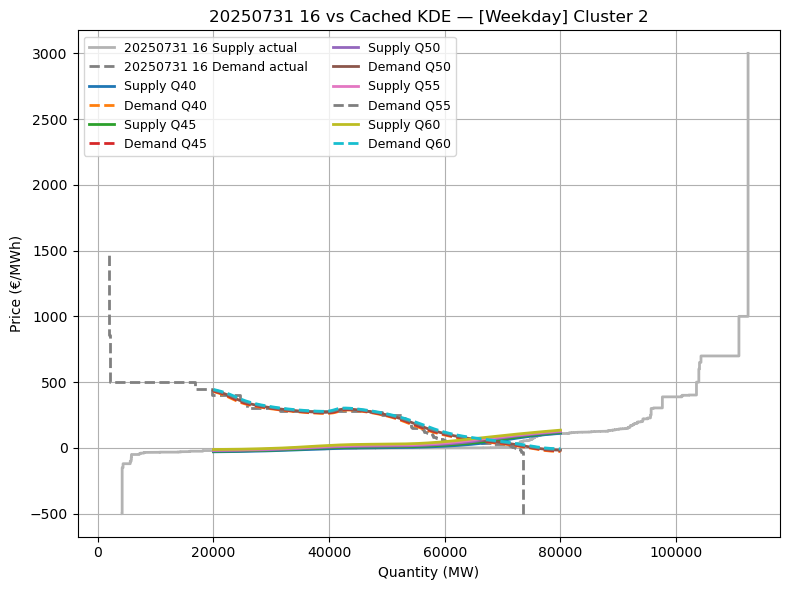

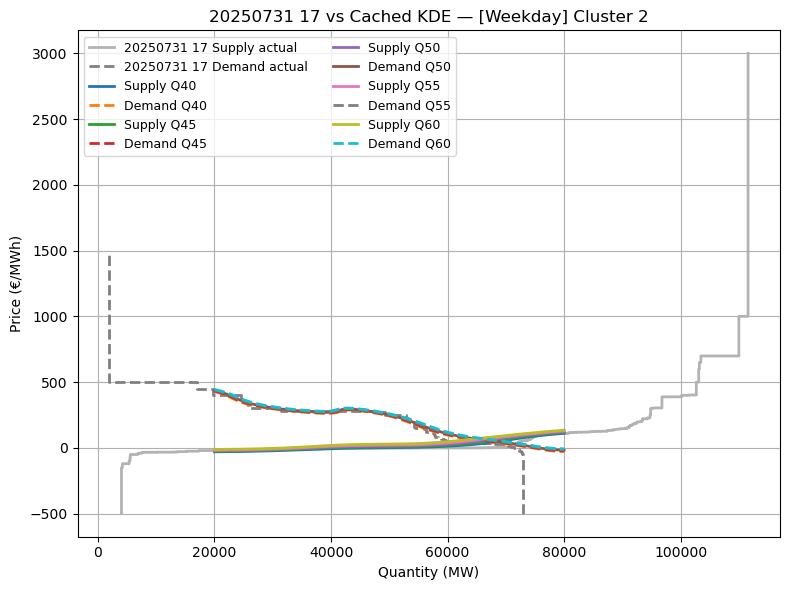

In [26]:
def plot_testday_vs_cached(df_test_supply, df_test_features, kde_cache, daytype_key, cluster_key, quantiles=quantiles):
    """
    df_test_features에 DayType/Cluster가 이미 붙어있다고 가정
    (붙이는 코드는 네가 이미 작성한 그대로 사용)
    """
    for _, row in df_test_features.iterrows():
        dt  = row["Datetime"]
        dty = "Weekend" if row["IsWeekend"] else "Weekday"
        cl  = row[cluster_key]  # 예: "Cluster" or "TCluster"

        if dty not in kde_cache or cl not in kde_cache[dty]:
            continue

        entry = kde_cache[dty][cl]
        q_grid_cached = entry["q_grid"]
        sup_curves_cached = entry["sup_curves"]
        dem_curves_cached = entry["dem_curves"]

        # 실제 테스트일 곡선 집계
        sub = df_test_supply[df_test_supply["Datetime"]==dt]
        sup = sub[sub["GC"]=="V"]; dem = sub[sub["GC"]=="C"]
        if sup.empty or dem.empty:
            continue
        s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
        s_agg["Cumul"] = s_agg["Amount"].cumsum()
        d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
        d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]

        # 플롯
        plt.figure(figsize=(8,6))
        plt.step(s_agg["Cumul"], s_agg["Price"], where="post", color="0.7", lw=2, label=f"{dt} Supply actual")
        plt.step(d_agg["Cumul"], d_agg["Price"], where="post", color="0.5", lw=2, linestyle="--", label=f"{dt} Demand actual")

        for qt in quantiles:
            if qt in sup_curves_cached:
                plt.plot(q_grid_cached, sup_curves_cached[qt], lw=2, label=f"Supply Q{int(qt*100)}")
            if qt in dem_curves_cached:
                style = "-" if abs(qt-0.5)<1e-9 else "--"
                plt.plot(q_grid_cached, dem_curves_cached[qt], lw=2, linestyle=style, label=f"Demand Q{int(qt*100)}")

        plt.title(f"{dt} vs Cached KDE — [{dty}] Cluster {cl}")
        plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
        plt.legend(ncol=2, fontsize=9); plt.grid(True); plt.tight_layout(); plt.show()

# 예시 호출:
plot_testday_vs_cached(df_test_supply, df_test_features, kde_cache, daytype_key="IsWeekend", cluster_key="TCluster" or "Cluster")

RDC 도출

In [27]:
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i],       resid[i+1]
            if r1 != r0:
                # 선형 보간으로 교차점 계산
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc

def rdc_from_modal_curves(q_grid, sup_p_of_q, dem_p_of_q, wf_offer_grid,
                          fill='extrapolate'):
    """
    modal 공급/수요(P(Q)) → Q(P)로 뒤집은 뒤,
    각 q_wf에 대해 D(P)-S(P)-q_wf = 0의 해 P를 찾는다.
    """
    invS = invert_P_of_Q_to_Q_of_P(q_grid, sup_p_of_q, fill=fill)
    invD = invert_P_of_Q_to_Q_of_P(q_grid, dem_p_of_q, fill=fill)
    if invS is None or invD is None:
        return []

    S_Q_of_P, Ps_min_S, Ps_max_S = invS
    D_Q_of_P, Ps_min_D, Ps_max_D = invD

    # 해 탐색 가능한 공통 가격 구간
    Pmin = max(Ps_min_S, Ps_min_D)
    Pmax = min(Ps_max_S, Ps_max_D)
    if not np.isfinite(Pmin) or not np.isfinite(Pmax) or Pmax <= Pmin:
        return []

    # 브래킷에서 부호변화 확인용 샘플 그리드
    Pgrid = np.linspace(Pmin, Pmax, 600)

    rdc_pts = []
    for q_wf in wf_offer_grid:
        # 잔차 함수: R(P) = D(P) - S(P) - q_wf
        R = D_Q_of_P(Pgrid) - S_Q_of_P(Pgrid) - q_wf
        sign = np.sign(R)
        flips = np.where(np.diff(np.sign(R)) != 0)[0]
        if len(flips) == 0:
            continue
        # 첫 번째 교차만 채택(원하면 모든 교차 반복)
        i = flips[0]
        a, b = Pgrid[i], Pgrid[i+1]
        def resid(P):
            return float(D_Q_of_P(P) - S_Q_of_P(P) - q_wf)
        try:
            sol = root_scalar(resid, bracket=[a, b], method='bisect')
            if sol.converged:
                rdc_pts.append((q_wf, sol.root))
        except Exception:
            pass

    return rdc_pts

def invert_P_of_Q_to_Q_of_P(q_grid, p_of_q, *, fill='extrapolate'):
    """
    modal처럼 얻은 P(Q)를 Q(P)로 뒤집는다.
    - P가 단조가 아닐 수 있어, P 기준으로 정렬하고 같은 P가 여러개면
      그 P에서의 '대표 Q'를 선택(여기선 평균)한다.
    """
    q = np.asarray(q_grid).astype(float)
    p = np.asarray(p_of_q).astype(float)

    # 유효값만
    m = np.isfinite(q) & np.isfinite(p)
    q, p = q[m], p[m]
    if len(q) < 4:
        return None  # 뒤집을 정보 부족

    # P 기준 정렬
    order = np.argsort(p)
    p_sorted = p[order]
    q_sorted = q[order]

    # 같은 P가 여러 개면 평균 Q 사용(원하면 최대/최소로 바꿔도 됨)
    # (정밀하게 하려면 binning 후 평균)a
    uniq_p, idxs = np.unique(p_sorted, return_inverse=True)
    q_acc = np.zeros_like(uniq_p, dtype=float)
    cnt   = np.zeros_like(uniq_p, dtype=float)
    for i, k in enumerate(idxs):
        q_acc[k] += q_sorted[i]
        cnt[k]   += 1.0
    q_rep = q_acc / np.maximum(cnt, 1.0)

    # 이제 Q(P) 보간 함수
    Q_of_P = interp1d(uniq_p, q_rep,
                      kind='linear', bounds_error=False, fill_value=fill)
    return Q_of_P, float(np.nanmin(uniq_p)), float(np.nanmax(uniq_p))

In [30]:
def _get_daytype_and_cluster_for_hour(df_test_features, date_str, hour, cluster_key="TCluster"):
    """해당 날짜/시간의 DayType(Weekend/Weekday)과 클러스터 id 반환"""
    dt = f"{date_str} {hour}"
    row = df_test_features[df_test_features["Datetime"] == dt]
    if row.empty:
        return None, None, dt
    is_weekend = bool(row["IsWeekend"].iloc[0])
    daytype = "Weekend" if is_weekend else "Weekday"
    # cluster_key 우선, 없으면 'Cluster'
    if cluster_key not in row.columns:
        ck = "Cluster" if "Cluster" in row.columns else None
    else:
        ck = cluster_key
    cl = int(row[ck].iloc[0]) if ck is not None and pd.notna(row[ck].iloc[0]) else None
    return daytype, cl, dt


def build_rdc_scenarios_for_hour(date_str, hour, df_test_supply, df_test_features, kde_cache,
                                 cluster_key="TCluster", save_csv_prefix=None, show_plot=True,
                                 quantiles=quantiles,
                                 wf_offer_grid=np.arange(0, 5000, 10)):
    """
    한 날짜의 특정 Hour(1~24)에 대해:
      - 해당 (DayType, Cluster)에서 캐시된 KDE 기반 S/D 분위수 곡선 불러오기
      - Supply×Demand 25개 조합 RDC 계산
      - 같은 시각의 실제 RDC 계산 (df_test_supply에서 Datetime 일치)
      - 그래프(옵션) + 블록(stepwise) CSV 저장(옵션)
    """
    daytype, cl, dt = _get_daytype_and_cluster_for_hour(df_test_features, date_str, hour, cluster_key)
    if daytype is None or cl is None:
        print(f"[{dt}] daytype/cluster 없음 → 스킵")
        return None

    if daytype not in kde_cache or cl not in kde_cache[daytype]:
        print(f"[{dt}] 캐시에 ({daytype}, cluster={cl}) 없음 → 스킵")
        return None

    entry = kde_cache[daytype][cl]
    q_grid_cached     = entry["q_grid"]
    sup_curves_cached = entry["sup_curves"]  # {qt: curve}
    dem_curves_cached = entry["dem_curves"]  # {qt: curve}

    # ========== KDE 기반 RDC (모든 조합) ==========
    scen_records = []
    scen_lines   = []  # (label, qv, pv)
    for sq in quantiles:
        s_curve = sup_curves_cached.get(sq, None)
        if s_curve is None: 
            continue
        for dq in quantiles:
            d_curve = dem_curves_cached.get(dq, None)
            if d_curve is None:
                continue
            rdc_pts = rdc_from_modal_curves(q_grid_cached, s_curve, d_curve, wf_offer_grid)
            if not rdc_pts:
                continue
            qv, pv = map(np.array, zip(*rdc_pts))
            scen = f"S{int(sq*100)}-D{int(dq*100)}"
            scen_lines.append((scen, qv, pv))

            # 블록(stepwise) 저장: 각 WF 구간의 중간점에서 가격 샘플
            q_breaks  = wf_offer_grid
            delta_qs  = np.diff(q_breaks)
            order     = np.argsort(qv)
            qv_sorted = qv[order]; pv_sorted = pv[order]
            for b, (q0, dq_step) in enumerate(zip(q_breaks[:-1], delta_qs)):
                mid = q0 + dq_step/2
                lam = float(np.interp(mid, qv_sorted, pv_sorted))
                scen_records.append({
                    "date": date_str, "hour": hour,
                    "scenario": scen, "daytype": daytype, "cluster": int(cl),
                    "block_id": b, "q_ini": float(q0), "dq": float(dq_step),
                    "lambda": lam
                })

    rdc_blocks_df = pd.DataFrame.from_records(scen_records)

    # ========== 실제 RDC (그 시간 dt 하나) ==========
    actual_lines = []
    sub = df_test_supply[df_test_supply["Datetime"] == dt]
    if not sub.empty:
        sup = sub[sub["GC"] == "V"]; dem = sub[sub["GC"] == "C"]
        if not sup.empty and not dem.empty:
            s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
            s_agg["Cumul"] = s_agg["Amount"].cumsum()
            d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
            d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]

            s_f = interp1d(s_agg["Price"], s_agg["Cumul"], kind="previous",
                           bounds_error=False, fill_value=(0, s_agg["Cumul"].iat[-1]))
            d_f = interp1d(d_agg["Price"], d_agg["Cumul"], kind="previous",
                           bounds_error=False, fill_value=(d_agg["Cumul"].iat[0], 0))
            Pmin = max(s_agg["Price"].min(), d_agg["Price"].min())
            Pmax = min(s_agg["Price"].max(), d_agg["Price"].max())
            if np.isfinite(Pmin) and np.isfinite(Pmax) and Pmax > Pmin:
                pg = np.linspace(Pmin, Pmax, 450)
                sv, dv = s_f(pg), d_f(pg)
                rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
                if rdc_pts:
                    qv, pv = map(np.array, zip(*rdc_pts))
                    actual_lines.append((f"Actual {dt}", qv, pv))

    # ========== Plot (RDC만) ==========
    if show_plot:
        plt.figure(figsize=(8,6))
        # KDE 시나리오
        for label, qv, pv in scen_lines:
            plt.plot(qv, pv, lw=1.0, alpha=0.75, label=label)
        # 실제
        for label, qv, pv in actual_lines:
            plt.plot(qv, pv, "k-", lw=2.2, label=label)

        plt.title(f"RDC — {date_str} Hour {hour:02d}  [{daytype} / Cluster {cl}]")
        plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
        plt.grid(True); plt.legend(ncol=2, fontsize=8)
        plt.tight_layout(); plt.show()

    # ========== CSV 저장 (옵션) ==========
    if save_csv_prefix:
        path = f"{save_csv_prefix}_{date_str}_{hour:02d}_rdc_blocks.csv"
        rdc_blocks_df.to_csv(path, index=False, encoding="utf-8-sig")
        print(f"[save] {path}  (rows={len(rdc_blocks_df)})")

    return rdc_blocks_df

In [ ]:


# ============================
# 사용 예시: 30일/31일, 1~24시 전부
# ============================
# quantiles, wf_offer_grid, q_grid, kde_cache, df_test_supply, df_test_features가 이미 준비되어 있다고 가정
quantiles = [0.4, 0.45, 0.5, 0.55, 0.6]
res_30 = []
for h in range(1, 25):
    dfh = build_rdc_scenarios_for_hour(
        "20250730", h,
        df_test_supply, df_test_features, kde_cache,
        cluster_key="TCluster",  # 필요시 "Cluster"로 변경
        save_csv_prefix="rdc_blocks_30", show_plot=True,
        quantiles=quantiles, wf_offer_grid=wf_offer_grid
    )
    if dfh is not None:
        res_30.append(dfh)
df_30_all = pd.concat(res_30, ignore_index=True) if res_30 else None

res_31 = []
for h in range(1, 25):
    dfh = build_rdc_scenarios_for_hour(
        "20250731", h,
        df_test_supply, df_test_features, kde_cache,
        cluster_key="TCluster",
        save_csv_prefix="rdc_blocks_31", show_plot=True,
        quantiles=quantiles, wf_offer_grid=wf_offer_grid
    )
    if dfh is not None:
        res_31.append(dfh)
df_31_all = pd.concat(res_31, ignore_index=True) if res_31 else None

이걸 사용

In [33]:
# ----------------------------------------------
# 필수 가정: 아래 객체/함수들이 이미 존재
# - kde_cache: {"Weekend": {cluster_id: {"q_grid":..., "sup_curves":{qt:curve}, "dem_curves":{qt:curve}}}, "Weekday": {...}}
# - df_test_supply: 테스트일(예: 20250730/31)의 원시 수요/공급 곡선 데이터 (Datetime, GC, Price, Amount ...)
# - df_test_features: 테스트일의 feature (Datetime, IsWeekend, TCluster 또는 Cluster ...)
# - compute_rdc_by_sign_change(price_grid, dv, sv, wf_offer_grid)
# - rdc_from_modal_curves(q_grid, s_curve, d_curve, wf_offer_grid)
# - quantiles, q_grid, wf_offer_grid
# ----------------------------------------------

def _get_daytype_and_cluster_for_hour(df_test_features, date_str, hour, cluster_key="TCluster"):
    """해당 날짜/시간의 DayType(Weekend/Weekday)과 클러스터 id 반환"""
    dt = f"{date_str} {hour}"
    row = df_test_features[df_test_features["Datetime"] == dt]
    if row.empty:
        return None, None, dt
    is_weekend = bool(row["IsWeekend"].iloc[0])
    daytype = "Weekend" if is_weekend else "Weekday"
    # cluster_key 우선, 없으면 'Cluster'
    if cluster_key not in row.columns:
        ck = "Cluster" if "Cluster" in row.columns else None
    else:
        ck = cluster_key
    cl = int(row[ck].iloc[0]) if ck is not None and pd.notna(row[ck].iloc[0]) else None
    return daytype, cl, dt


def build_rdc_scenarios_for_hour(date_str, hour, df_test_supply, df_test_features, kde_cache,
                                 cluster_key="TCluster", save_csv_prefix=None, show_plot=True,
                                 quantiles=(0.1,0.3,0.5,0.7,0.9),
                                 wf_offer_grid=np.arange(0, 5000, 10)):
    """
    한 날짜의 특정 Hour(1~24)에 대해:
      - 해당 (DayType, Cluster)에서 캐시된 KDE 기반 S/D 분위수 곡선 불러오기
      - Supply×Demand 25개 조합 RDC 계산
      - 같은 시각의 실제 RDC 계산 (df_test_supply에서 Datetime 일치)
      - 그래프(옵션) + 블록(stepwise) CSV 저장(옵션)
    """
    daytype, cl, dt = _get_daytype_and_cluster_for_hour(df_test_features, date_str, hour, cluster_key)
    if daytype is None or cl is None:
        print(f"[{dt}] daytype/cluster 없음 → 스킵")
        return None

    if daytype not in kde_cache or cl not in kde_cache[daytype]:
        print(f"[{dt}] 캐시에 ({daytype}, cluster={cl}) 없음 → 스킵")
        return None

    entry = kde_cache[daytype][cl]
    q_grid_cached     = entry["q_grid"]
    sup_curves_cached = entry["sup_curves"]  # {qt: curve}
    dem_curves_cached = entry["dem_curves"]  # {qt: curve}

    # ========== KDE 기반 RDC (모든 조합) ==========
    scen_records = []
    scen_lines   = []  # (label, qv, pv)
    for sq in quantiles:
        s_curve = sup_curves_cached.get(sq, None)
        if s_curve is None: 
            continue
        for dq in quantiles:
            d_curve = dem_curves_cached.get(dq, None)
            if d_curve is None:
                continue
            rdc_pts = rdc_from_modal_curves(q_grid_cached, s_curve, d_curve, wf_offer_grid)
            if not rdc_pts:
                continue
            qv, pv = map(np.array, zip(*rdc_pts))
            scen = f"S{int(sq*100)}-D{int(dq*100)}"
            scen_lines.append((scen, qv, pv))

            # 블록(stepwise) 저장: 각 WF 구간의 중간점에서 가격 샘플
            q_breaks  = wf_offer_grid
            delta_qs  = np.diff(q_breaks)
            order     = np.argsort(qv)
            qv_sorted = qv[order]; pv_sorted = pv[order]
            for b, (q0, dq_step) in enumerate(zip(q_breaks[:-1], delta_qs)):
                mid = q0 + dq_step/2
                lam = float(np.interp(mid, qv_sorted, pv_sorted))
                scen_records.append({
                    "date": date_str, "hour": hour,
                    "scenario": scen, "daytype": daytype, "cluster": int(cl),
                    "block_id": b, "q_ini": float(q0), "dq": float(dq_step),
                    "lambda": lam
                })

    rdc_blocks_df = pd.DataFrame.from_records(scen_records)

    # ========== 실제 RDC (그 시간 dt 하나) ==========
    actual_lines = []
    sub = df_test_supply[df_test_supply["Datetime"] == dt]
    if not sub.empty:
        sup = sub[sub["GC"] == "V"]; dem = sub[sub["GC"] == "C"]
        if not sup.empty and not dem.empty:
            s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
            s_agg["Cumul"] = s_agg["Amount"].cumsum()
            d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
            d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]

            s_f = interp1d(s_agg["Price"], s_agg["Cumul"], kind="previous",
                           bounds_error=False, fill_value=(0, s_agg["Cumul"].iat[-1]))
            d_f = interp1d(d_agg["Price"], d_agg["Cumul"], kind="previous",
                           bounds_error=False, fill_value=(d_agg["Cumul"].iat[0], 0))
            Pmin = max(s_agg["Price"].min(), d_agg["Price"].min())
            Pmax = min(s_agg["Price"].max(), d_agg["Price"].max())
            if np.isfinite(Pmin) and np.isfinite(Pmax) and Pmax > Pmin:
                pg = np.linspace(Pmin, Pmax, 450)
                sv, dv = s_f(pg), d_f(pg)
                rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
                if rdc_pts:
                    qv, pv = map(np.array, zip(*rdc_pts))
                    actual_lines.append((f"Actual {dt}", qv, pv))

    # ========== Plot (RDC만) ==========
    if show_plot:
        plt.figure(figsize=(8,6))

        # KDE 시나리오: stepwise로 그리기
        for scen in sorted(set(r["scenario"] for r in scen_records)):
            # 이 시나리오의 블록 레코드만 꺼내서 λ 순서대로 정렬
            sub = [r for r in scen_records if r["scenario"] == scen]
            if not sub:
                continue
            sub = sorted(sub, key=lambda r: r["block_id"])
            q_breaks = wf_offer_grid  # 우리가 사용한 동일한 블록 경계
            lambdas  = [r["lambda"] for r in sub]
            X, Y = _make_step_xy(q_breaks, lambdas)
            plt.plot(X, Y, lw=1.0, alpha=0.75, label=scen)

        # 실제 RDC도 같은 블록 그리드의 중간점에서 λ를 샘플해 stepwise로 표현
        for label, qv, pv in actual_lines:
            order = np.argsort(qv)
            qv_sorted, pv_sorted = qv[order], pv[order]
            mids = (wf_offer_grid[:-1] + wf_offer_grid[1:]) / 2.0
            lam_actual = np.interp(mids, qv_sorted, pv_sorted, left=np.nan, right=np.nan)
            mask = np.isfinite(lam_actual)
            if mask.sum() > 1:
                X, Y = _make_step_xy(wf_offer_grid[mask.tolist()+[mask.tolist()[-1]+1] if False else np.arange(len(wf_offer_grid))], lam_actual[mask])
                # 위 한 줄은 마스크로 경계 처리 복잡해져서, 실무에선 그냥 전체 구간 쓰고 NaN 처리 권장:
                X, Y = _make_step_xy(wf_offer_grid, lam_actual)  # 간단 버전(약간의 외삽 허용)
                plt.plot(X, Y, "k-", lw=2.0, label=f"{label} (step)")

        plt.title(f"RDC — {date_str} Hour {hour:02d}  [{daytype} / Cluster {cl}]")
        plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
        plt.grid(True); plt.legend(ncol=2, fontsize=8)
        plt.tight_layout(); plt.show()


    return rdc_blocks_df



In [35]:
def _make_step_xy(q_breaks, lambdas):
    """q_breaks: WF 오퍼 구간 경계 (len = B+1), lambdas: 각 블록 λ (len = B)
       stepwise 플롯용 X, Y 생성 (post 계단)"""
    q0 = q_breaks[:-1]
    q1 = q_breaks[1:]
    # 수평 구간을 2점씩 반복해서 그리기
    X = np.repeat(np.column_stack([q0, q1]), 1, axis=1).ravel()
    Y = np.repeat(lambdas, 2)
    # 경계에서 수직 점프를 보이고 싶으면 아래 두 줄을 추가로 그려도 됨
    return X, Y

In [ ]:
wf_offer_grid = np.arange(0, 5000, 1000)

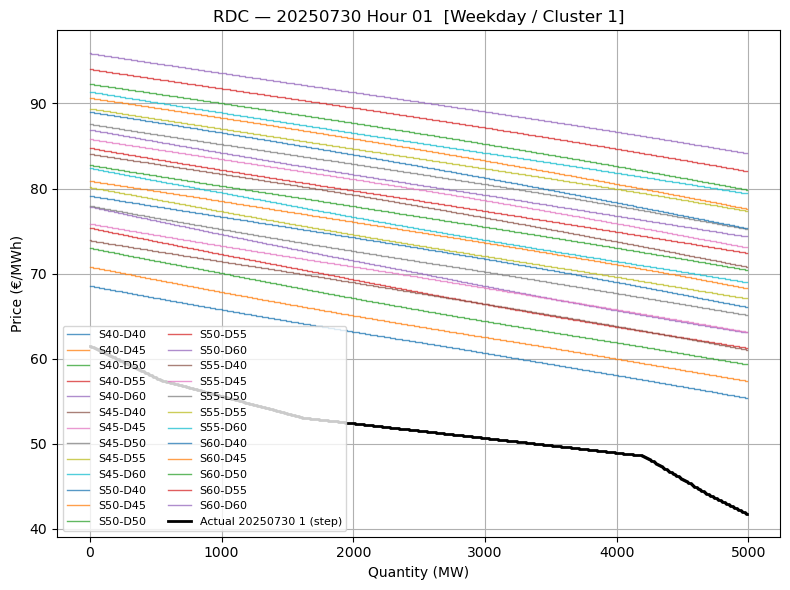

KeyboardInterrupt: 

In [ ]:
# ============================
# 사용 예시: 30일/31일, 1~24시 전부

# ============================
# quantiles, wf_offer_grid, q_grid, kde_cache, df_test_supply, df_test_features가 이미 준비되어 있다고 가정
quantiles = [0.4, 0.45, 0.5, 0.55, 0.6]

res_30 = []
for h in range(1, 25):
    dfh = build_rdc_scenarios_for_hour(
        "20250730", h,
        df_test_supply, df_test_features, kde_cache,
        cluster_key="TCluster",  # 필요시 "Cluster"로 변경
        save_csv_prefix="rdc_blocks_30", show_plot=True,
        quantiles=quantiles, wf_offer_grid=wf_offer_grid
    )
    if dfh is not None:
        res_30.append(dfh)
df_30_all = pd.concat(res_30, ignore_index=True) if res_30 else None

res_31 = []
for h in range(1, 25):
    dfh = build_rdc_scenarios_for_hour(
        "20250731", h,
        df_test_supply, df_test_features, kde_cache,
        cluster_key="TCluster",
        save_csv_prefix="rdc_blocks_31", show_plot=True,
        quantiles=quantiles, wf_offer_grid=wf_offer_grid
    )
    if dfh is not None:
        res_31.append(dfh)
df_31_all = pd.concat(res_31, ignore_index=True) if res_31 else None

In [39]:
print(df_test_supply["Datetime"].unique()[:10])


['20250730 1' '20250730 2' '20250730 3' '20250730 4' '20250730 5'
 '20250730 6' '20250730 7' '20250730 8' '20250730 9' '20250730 10']


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_22112\2645236465.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


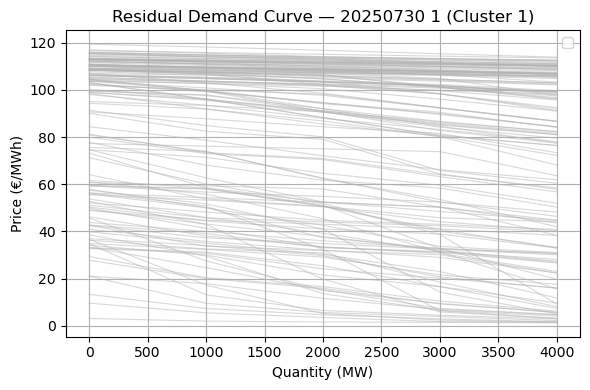

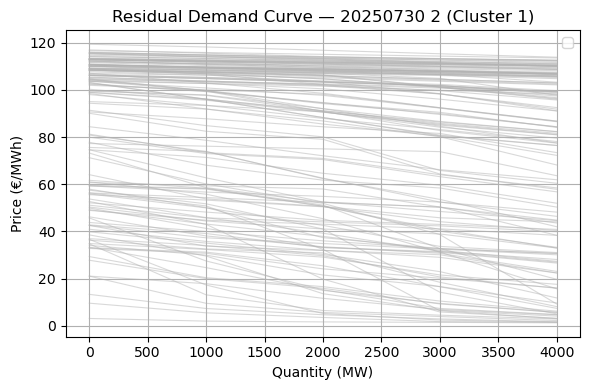

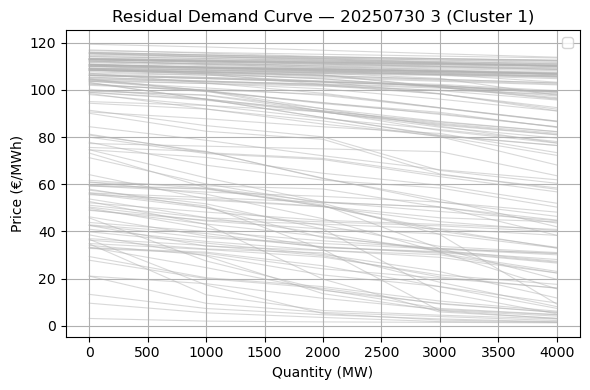

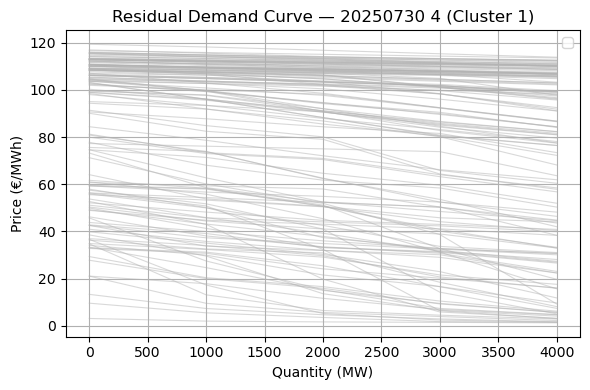

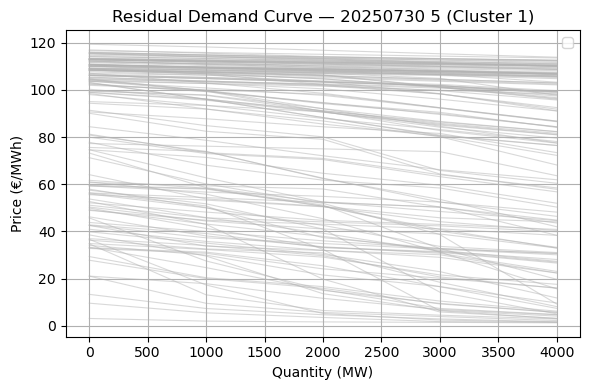

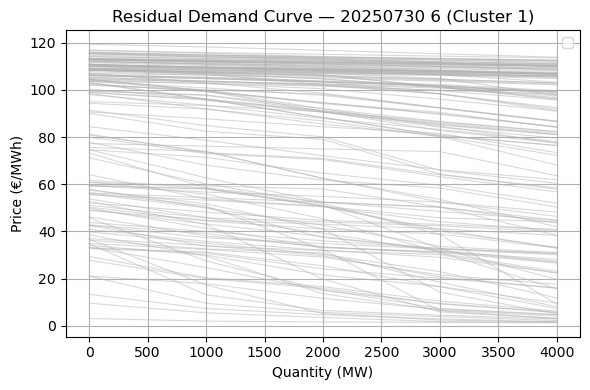

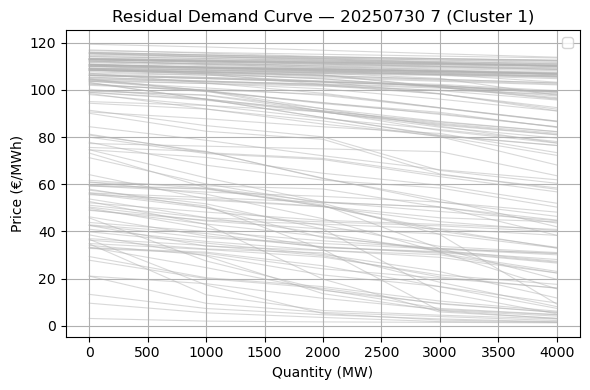

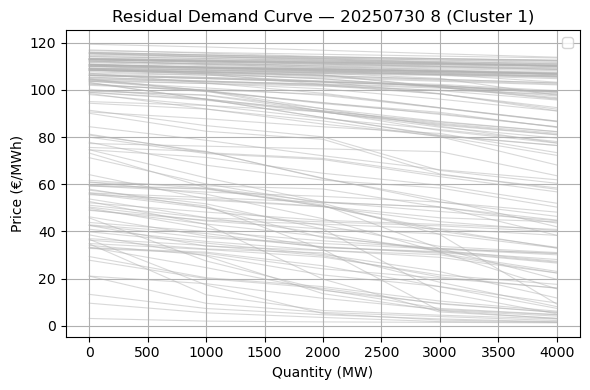

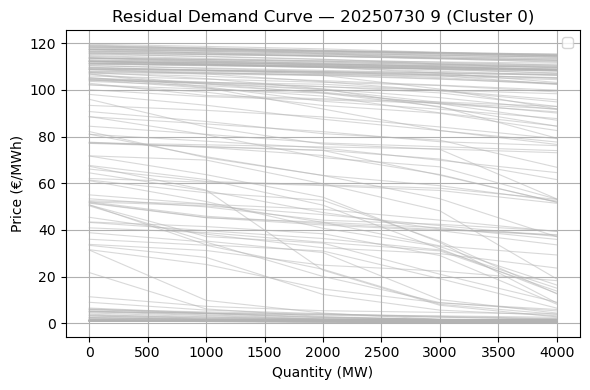

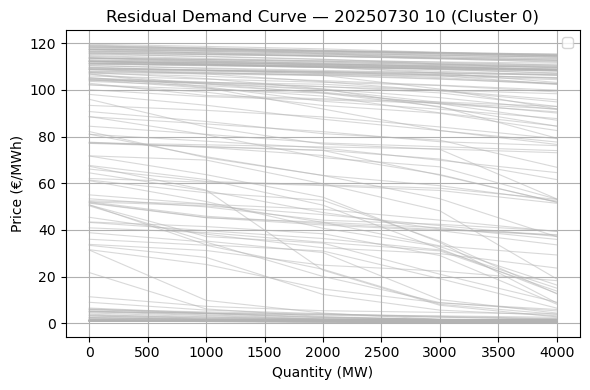

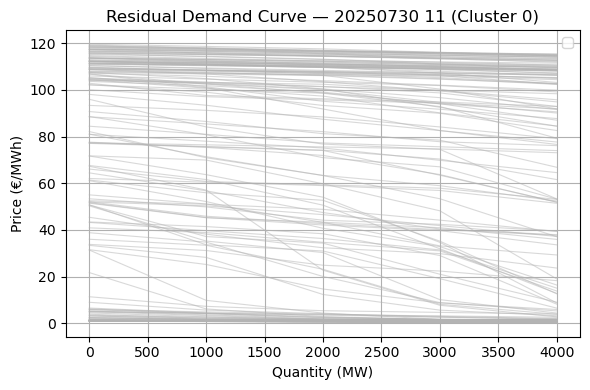

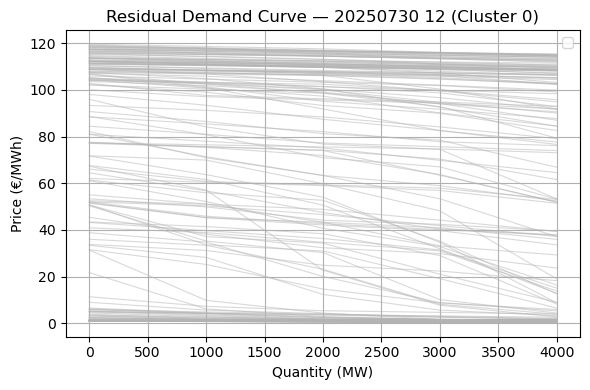

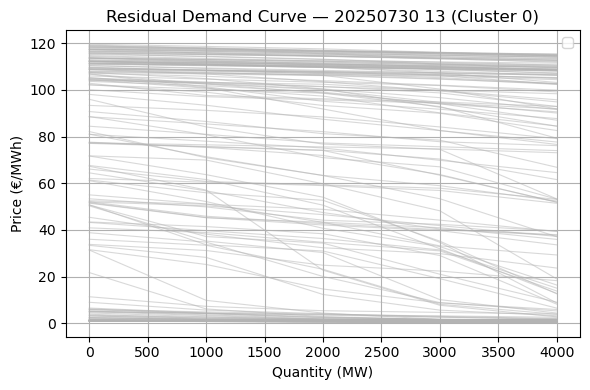

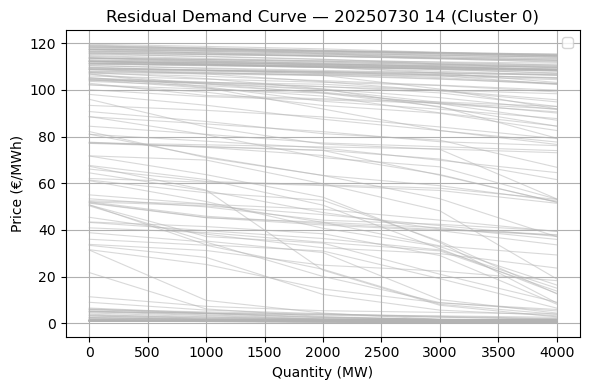

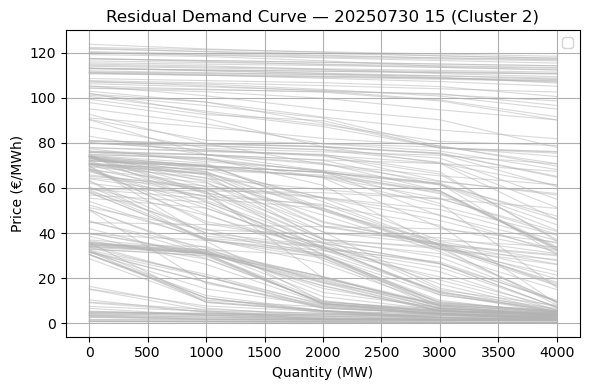

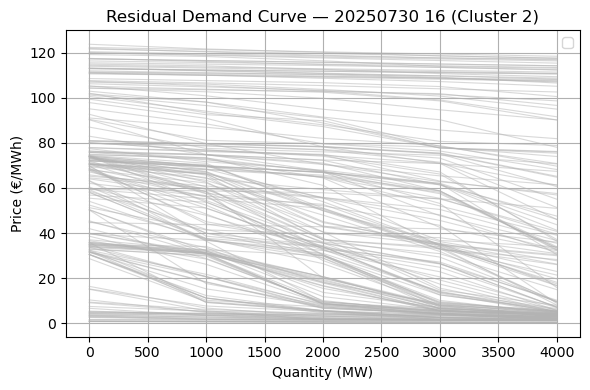

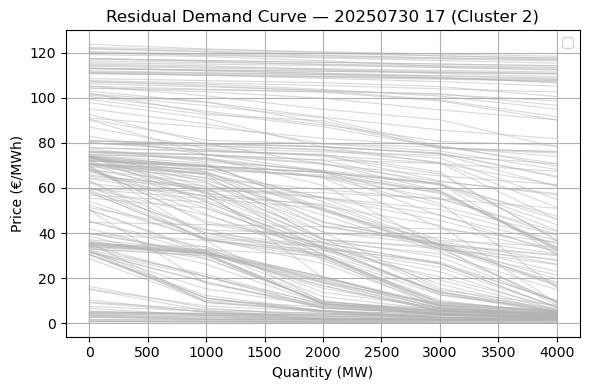

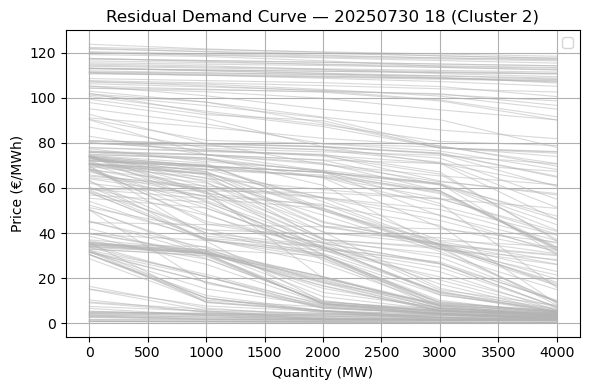

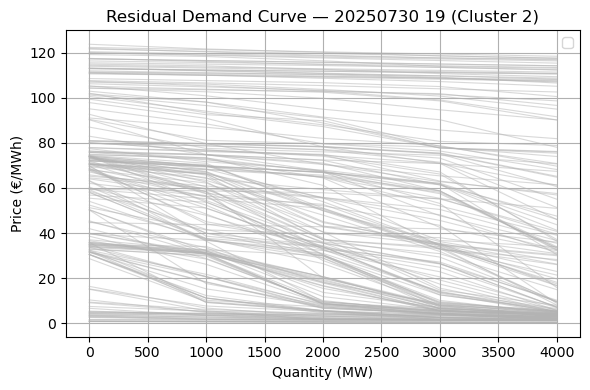

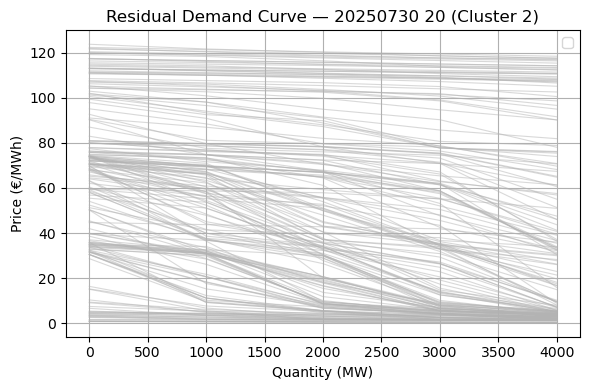

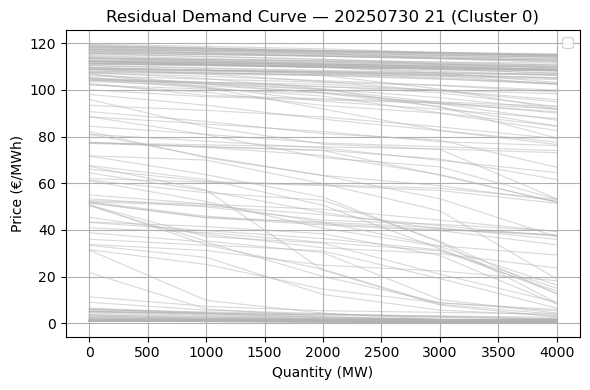

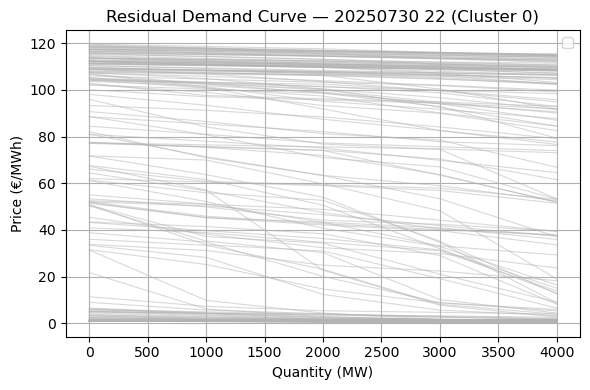

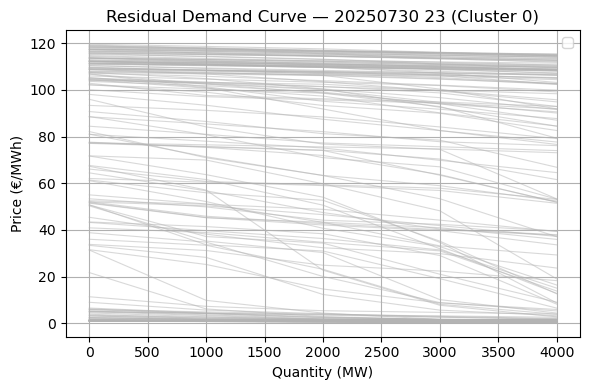

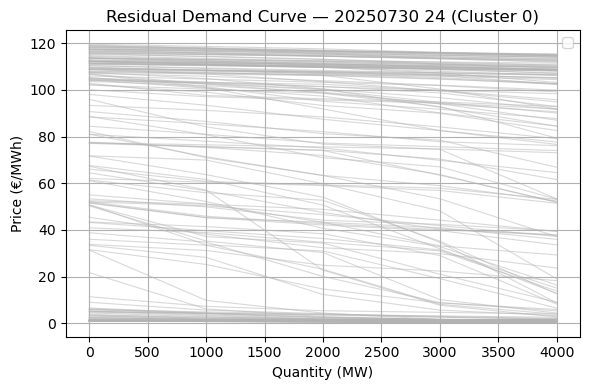

In [38]:

# --- 공통 설정 ---
wf_offer_grid = np.arange(0, 5000, 1000)  # step size 원하는 대로 조정
q_grid = np.linspace(20000, 80000, 300)

# === 7월 30일 Datetime 필터 ===
target_date = "20250730"

# === 시간대별 반복 ===
for hour in range(1, 25):   # 1~24시
    dt = f"{target_date} {hour}"
    
    # 30일 해당 시간대의 클러스터
    row = df_test_features[df_test_features["Datetime"] == dt]
    if row.empty:
        continue
    isweekend = bool(row["IsWeekend"].iloc[0])
    cl = row["TCluster"].iloc[0]

    # 해당 클러스터에 포함된 멤버들
    members = [cur for cur in supply_curves if cur.get("IsWeekend")==isweekend and cur.get("TCluster")==cl]
    if not members:
        continue

    # === 플롯 ===
    plt.figure(figsize=(6,4))
    
    # 1) 같은 클러스터 다른 날짜 RDC (회색 얇게)
    for cur in members:
        s, d = cur["Supply"], cur["Demand"]
        fS = interp1d(s["Price"], s["Cumul"], kind="previous", bounds_error=False, fill_value=(0, s["Cumul"].iat[-1]))
        fD = interp1d(d["Price"], d["Cumul"], kind="previous", bounds_error=False, fill_value=(d["Cumul"].iat[0], 0))
        P = np.linspace(max(s["Price"].min(), d["Price"].min()), min(s["Price"].max(), d["Price"].max()), 500)
        sv, dv = fS(P), fD(P)
        rdc_pts = compute_rdc_by_sign_change(P, dv, sv, wf_offer_grid)
        if rdc_pts:
            qv, pv = zip(*rdc_pts)
            plt.plot(qv, pv, color="0.7", lw=0.8, alpha=0.5)

    # 2) 7월 30일 해당 시간 RDC (굵게 검정색)
    cur30 = [cur for cur in members if cur["Datetime"] == dt]
    for cur in cur30:
        s, d = cur["Supply"], cur["Demand"]
        fS = interp1d(s["Price"], s["Cumul"], kind="previous", bounds_error=False, fill_value=(0, s["Cumul"].iat[-1]))
        fD = interp1d(d["Price"], d["Cumul"], kind="previous", bounds_error=False, fill_value=(d["Cumul"].iat[0], 0))
        P = np.linspace(max(s["Price"].min(), d["Price"].min()), min(s["Price"].max(), d["Price"].max()), 500)
        sv, dv = fS(P), fD(P)
        rdc_pts = compute_rdc_by_sign_change(P, dv, sv, wf_offer_grid)
        if rdc_pts:
            qv, pv = zip(*rdc_pts)
            plt.plot(qv, pv, color="k", lw=2.5, label="July 30 RDC")

    plt.title(f"Residual Demand Curve — {dt} (Cluster {cl})")
    plt.xlabel("Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
